# ***RNA-seq analysis***
----
> **数据**：TCGA的RNA-seq数据

In [1]:
rm(list = ls())
options(stringsAsFactors = FALSE)
getwd()

[1] "/Users/luye/Library/Mobile Documents/com~apple~CloudDocs/Projects/Done/202309MLT/2-TCGAanalysis"

In [3]:
### Load packages
library(dplyr)
library(tidyverse)
library(ggplot2)
library(data.table)
library(ComplexHeatmap)
library(TCGAbiolinks)
library(TCGAplot)
library(SummarizedExperiment)
library(stringr)
library(DESeq2)
library(AnnotationDbi)
library(org.Hs.eg.db)
library(clusterProfiler)
library(circlize)
library(ggpubr)
library(RColorBrewer)
library(IOBR)

## **1-Data preparation**

In [ ]:
###############========== Data Download ==========################
### 使用TCGAbiolinks处理数据，常规需要3步走，分别是检索、下载和读取数据，依次对应以下3个函数 GDCquery()、GDCdownload() 和 GDCprepare() 
query <- GDCquery(project = "TCGA-ESCA",
                  data.category = "Transcriptome Profiling",
                  data.type = "Gene Expression Quantification",
                  workflow.type = "STAR - Counts")

In [ ]:
GDCdownload(query) # 下载

In [ ]:
# 整理
exprSet <- GDCprepare(query, save = T, save.filename ="TCGA-ESCA_mRNA.Rdata") #保存对象，便于后续使用

In [9]:
assayNames(exprSet) #使用assayNames()函数查看包含的数据名称

[1] "unstranded"       "stranded_first"   "stranded_second"  "tpm_unstrand"    
[5] "fpkm_unstrand"    "fpkm_uq_unstrand"

In [4]:
rm(list = ls())
load(file = "./DEG/TSCC_tumor.Rdata")
ls()

[1] "TSCC_clin"     "TSCC_clin_T"   "TSCC_counts"   "TSCC_counts_T"
[5] "TSCC_log"      "TSCC_log_T"    "plot_data"

In [5]:
head(TSCC_counts)[, 1:2]
dim(TSCC_counts)

,TCGA-CR-7401-01A-11R-2016-07,TCGA-CQ-A4CE-01A-11R-A266-07
,<int>,<int>
5S_rRNA,0,2
5_8S_rRNA,0,0
7SK,0,0
A1BG,8,2
A1BG-AS1,9,11
A1CF,1,2


[1] 59427   140

In [6]:
head(TSCC_counts_T)[, 1:2]
dim(TSCC_counts_T)

,TCGA-CR-7401-01A-11R-2016-07,TCGA-CQ-A4CE-01A-11R-A266-07
,<int>,<int>
5S_rRNA,0,2
5_8S_rRNA,0,0
7SK,0,0
A1BG,8,2
A1BG-AS1,9,11
A1CF,1,2


[1] 59427   127

In [7]:
head(TSCC_clin_T)

barcode,patient,sample_type_id,sample_type,ajcc_pathologic_stage,tissue_or_organ_of_origin,ajcc_clinical_stage,ajcc_clinical_m,ajcc_clinical_n,ajcc_clinical_t,gender,vital_status,age_at_index,days_to_death,days_to_last_follow_up,Group,Age
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
TCGA-CR-7401-01A-11R-2016-07,TCGA-CR-7401,01,Primary Tumor,Stage I,"Tongue, NOS",I/II,M0,N0,T1,male,Alive,64,NA,1077,Tumor,>50 years
TCGA-CQ-A4CE-01A-11R-A266-07,TCGA-CQ-A4CE,01,Primary Tumor,Stage II,"Tongue, NOS",I/II,M0,N0,T2,female,Alive,76,NA,897,Tumor,>50 years
TCGA-CV-6959-01A-11R-1915-07,TCGA-CV-6959,01,Primary Tumor,Stage III,"Tongue, NOS",III,M0,N1,T3,male,Dead,48,256,NA,Tumor,<U+2264>50 years
TCGA-CV-7104-01A-11R-2016-07,TCGA-CV-7104,01,Primary Tumor,Stage IVA,"Tongue, NOS",IV,M0,N2,T2,female,Dead,61,393,NA,Tumor,>50 years
TCGA-DQ-5624-01A-01R-1873-07,TCGA-DQ-5624,01,Primary Tumor,NA,"Tongue, NOS",IV,M0,N1,T4a,female,Alive,43,NA,1778,Tumor,<U+2264>50 years
TCGA-HD-8635-01A-11R-2403-07,TCGA-HD-8635,01,Primary Tumor,Stage III,"Tongue, NOS",III,M0,N1,T1,female,Alive,61,NA,695,Tumor,>50 years


In [8]:
ICAM1 <- TSCC_log_T["ICAM1",]
head(ICAM1)

,TCGA-CR-7401-01A-11R-2016-07,TCGA-CQ-A4CE-01A-11R-A266-07,TCGA-CV-6959-01A-11R-1915-07,TCGA-CV-7104-01A-11R-2016-07,TCGA-DQ-5624-01A-01R-1873-07,TCGA-HD-8635-01A-11R-2403-07,TCGA-CV-6939-01A-11R-1915-07,TCGA-UP-A6WW-01A-12R-A34R-07,TCGA-MT-A67A-01A-11R-A30B-07,TCGA-CR-6488-01A-12R-2081-07,...,TCGA-CV-6433-01A-11R-1686-07,TCGA-CQ-7072-01A-21R-A30B-07,TCGA-CQ-6224-01A-11R-1915-07,TCGA-D6-A4ZB-01A-11R-A24Z-07,TCGA-BA-7269-01A-11R-2016-07,TCGA-C9-A480-01A-12R-A24H-07,TCGA-BB-A6UO-01A-12R-A34R-07,TCGA-CR-7382-01A-11R-2132-07,TCGA-H7-A6C4-01A-11R-A30B-07,TCGA-CN-6019-01A-11R-1686-07
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ICAM1,10.55938,10.24555,13.41521,13.53284,12.0461,11.04508,14.16428,12.8496,7.108524,11.92035,...,13.30007,11.70347,12.34568,10.26562,8.70044,11.11114,11.21006,13.74168,11.1605,13.13346


In [9]:
ICAM1 <- data.frame(t(ICAM1))
head(ICAM1)

,ICAM1
,<dbl>
TCGA-CR-7401-01A-11R-2016-07,10.55938
TCGA-CQ-A4CE-01A-11R-A266-07,10.24555
TCGA-CV-6959-01A-11R-1915-07,13.41521
TCGA-CV-7104-01A-11R-2016-07,13.53284
TCGA-DQ-5624-01A-01R-1873-07,12.04610
TCGA-HD-8635-01A-11R-2403-07,11.04508


In [10]:
ICAM1 <- rownames_to_column(ICAM1, "Sample")

In [11]:
ICAM1 <- inner_join(ICAM1, TSCC_clin_T, by = c("Sample" = "barcode"))

In [12]:
table(ICAM1$ajcc_clinical_stage)


I/II  III   IV 
  44   32   47 

## **2-单基因分析**

### **2.1 预后分析**

In [ ]:
### 预后分析
library(survminer)
library(survival)

In [ ]:
ICAM1_OS <- ICAM1[,c(1,2,3,13,15,16)]
dim(ICAM1_OS)

[1] 127   6

In [ ]:
head(ICAM1_OS)

,Sample,ICAM1,patient,vital_status,days_to_death,days_to_last_follow_up
,<chr>,<dbl>,<chr>,<chr>,<int>,<int>
1,TCGA-CR-7401-01A-11R-2016-07,10.55938,TCGA-CR-7401,Alive,NA,1077
2,TCGA-CQ-A4CE-01A-11R-A266-07,10.24555,TCGA-CQ-A4CE,Alive,NA,897
3,TCGA-CV-6959-01A-11R-1915-07,13.41521,TCGA-CV-6959,Dead,256,NA
4,TCGA-CV-7104-01A-11R-2016-07,13.53284,TCGA-CV-7104,Dead,393,NA
5,TCGA-DQ-5624-01A-01R-1873-07,12.04610,TCGA-DQ-5624,Alive,NA,1778
6,TCGA-HD-8635-01A-11R-2403-07,11.04508,TCGA-HD-8635,Alive,NA,695


In [ ]:
# 计算生存时间
ICAM1_OS$days_to_death[ICAM1_OS$days_to_death=="NA"] <- 0   #缺失值标记为0
ICAM1_OS$days_to_last_follow_up[ICAM1_OS$days_to_last_follow_up=="NA"] <- 0
ICAM1_OS$days = as.numeric(ICAM1_OS$days_to_death) + as.numeric(ICAM1_OS$days_to_last_follow_up)
k1 = ICAM1_OS$days >= 30
k2 = !(is.na(ICAM1_OS$days)|is.na(ICAM1_OS$vital_status))
ICAM1 = ICAM1_OS[k1&k2,]
dim(ICAM1_OS)

[1] 127   7

In [ ]:
# 时间以月份记，保留两位小数
ICAM1_OS$time=round(ICAM1_OS$days/30,2)
# 根据生死定义活着是0，死的是1
ICAM1_OS$Status = ifelse(ICAM1_OS$vital_status == 'Alive',0,1)
dim(ICAM1_OS)

[1] 127   9

In [ ]:
ICAM1_OS$Status <- factor(ICAM1_OS$Status)
summary(ICAM1_OS$Status)

0  1 
77 50

In [ ]:
qx <- as.numeric(quantile(ICAM1_OS$ICAM1, c(0., 0.25, 0.33, 0.5, 0.66, 0.75, 1.0), na.rm=T))
ICAM1_OS$Group <- "Low"
more.med.index <- which(ICAM1_OS$ICAM1>qx[4])
ICAM1_OS$Group[more.med.index] <- 'High'
dim(ICAM1_OS)
table(ICAM1_OS$Group)

[1] 127  10


High  Low 
  63   64 

In [ ]:
save(ICAM1_OS, file = "TCGA-TSCC_OSdata.Rdata")

In [ ]:
ICAM1_OS$Group <- factor(ICAM1_OS$Group, levels = c("High","Low"))

In [ ]:
fit <- survfit(Surv(time, Status==1) ~ Group, data = ICAM1_OS)

Warning message in geom_segment(aes(x = 0, y = max(y2), xend = max(x1), yend = max(y2)), :
"All aesthetics have length 1, but the data has 2 rows.
i Please consider using `annotate()` or provide this layer with data containing
  a single row."
Warning message in geom_segment(aes(x = 0, y = max(y2), xend = max(x1), yend = max(y2)), :
"All aesthetics have length 1, but the data has 2 rows.
i Please consider using `annotate()` or provide this layer with data containing
  a single row."


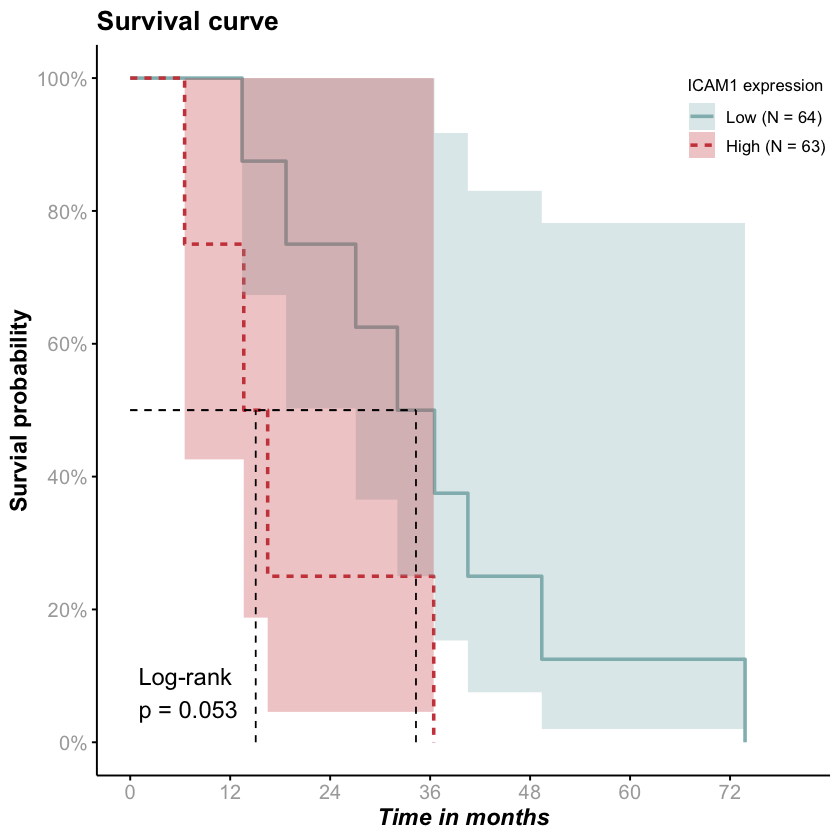

In [ ]:
ggsurvplot(fit, 
           title  = "Survival curve",  
           xlab = "Time in months", 
           ylab = "Survial probability", 
           font.main = c(16, "bold", "black"), #字体大小，样式和颜色
           font.x = c(14,  "bold.italic","black"), #x轴标签的字体大小，斜体和颜色
           font.y = c(14, "bold", "black"), #y轴的字体大小，颜色
           font.tickslab = c(12, "plain", "darkgrey"), #更改刻度标签的字体大小，样式和颜色
           legend = c(0.9, 0.9), 
           legend.title = "ICAM1 expression", 
           legend.labs = c("Low (N = 64)","High (N = 63)"), 
           #palette ="jco", 
           palette =c("#91BABB","#CD474A"),
           size = 1,  #更改线号
           linetype = "strata", #按组更改线型（即“分层”）
           break.x.by=12 ,
           break.y.by=0.2 ,
           surv.scale="percent" ,
           conf.int = T, 
           pval = TRUE, 
           pval.coord = c(1, 0.05),    
           pval.size = 5, 
           pval.method=TRUE,
           pval.method.size=5, 
           pval.method.coord=c(1,0.1),
           surv.median.line = "hv", 
           ylim = c(0, 1)
)

### **2.2 差异分析**

In [ ]:
p = identical(TSCC_clin_T$barcode,colnames(TSCC_counts_T));p #(3)让expr列名与pdata的行名顺序>完全一致

[1] TRUE

In [ ]:
TSCC_clin_T$Group <- ICAM1_OS$Group[match(TSCC_clin_T$barcode,ICAM1_OS$Sample)]

In [ ]:
### 创建datTraits，包含分组、表型等信息
group <- factor(TSCC_clin_T$Group)

design <- data.frame(counts_id = colnames(TSCC_counts_T),
                         group = group)
datTraits <- column_to_rownames(design, "counts_id")

In [ ]:
### 给分组加上编号
grouptype <- data.frame(group = sort(unique(datTraits$group)),
                      groupNo = 1 : length(unique(datTraits$group)))

datTraits$groupNo = "NA"
for (i in 1:nrow(grouptype)){
    datTraits[which(datTraits$group == grouptype$group[i]),'groupNo'] <- grouptype$groupNo[i]
    }
head(datTraits)

### 保存数据
save(count, group, datTraits, file = "./ICAM1_DEG_input.Rdata")

,group,groupNo
,<fct>,<chr>
TCGA-CR-7401-01A-11R-2016-07,Low,2
TCGA-CQ-A4CE-01A-11R-A266-07,Low,2
TCGA-CV-6959-01A-11R-1915-07,High,1
TCGA-CV-7104-01A-11R-2016-07,High,1
TCGA-DQ-5624-01A-01R-1873-07,High,1
TCGA-HD-8635-01A-11R-2403-07,Low,2


In [ ]:
### Comparision setting
compare <- data.frame(Test = c("High vs Low"),
                      denominator = c("Low"),
                      numerator = c("High"))
compare

Test,denominator,numerator
<chr>,<chr>,<chr>
High vs Low,Low,High


In [ ]:
### load input and set output files
file_in <- "counts.txt"
file_design <- "design.txt"
file_compare <- "compare2.txt"

file_deg_num <- paste("DE_", file_in, sep = "") ##number of DEGs in all compare
file_final_csv <- paste("DE_", file_in, "_Final_Out.csv", sep = "")
file_final_genelist <- paste("DEG_geneid_allcomapre.txt", sep = "")

countData <- as.data.frame(TSCC_counts_T)
dim(countData)
mycounts_filter <- countData[rowSums(countData) != 0, ]
dim(mycounts_filter)

mydesign <- rownames_to_column(datTraits, "counts_id")

total_num <- dim(compare)[1]  ##get the num of groups

[1] 59427   127

[1] 54907   127

In [ ]:
################========== DESeq2 差异分析 ==========################
tracking = 0
gene_num_out = c()
#pvalue_cut = 0.05
condition_name = c()

for (index_num in c(1:total_num)){
    tracking = tracking + 1
  
    test_name = as.character(compare[index_num,1])
    group1 = as.character(compare[index_num, 2])
    group2 = as.character(compare[index_num, 3])
    sample1 = mydesign[mydesign$group == group1,]
    sample2 = mydesign[mydesign$group == group2,]
  
    allsample = rbind(sample1, sample2)
    counts_sample = as.character(allsample$counts_id)
    groupreal = as.character(allsample$group)
    countData = mycounts_filter[, counts_sample]
    colData = as.data.frame(cbind(counts_sample, groupreal))
    names(colData) = c("sample", "condition")
  
    dds <- DESeqDataSetFromMatrix(countData = countData,
                                  colData = colData,
                                  design = ~ condition)
  
    dds <- DESeq(dds)
  
    resSFtreatment <- results(dds, cooksCutoff = FALSE, contrast = c("condition", group2, group1))
  
    out_test <- as.data.frame(resSFtreatment)
    final_each <- cbind(out_test$log2FoldChange, out_test$pvalue, out_test$padj)
    rownames(final_each) <- resSFtreatment@rownames
    names <- c('(log2FC)', '(pvalue)', '(padj)')
    final_name <- paste(test_name, '_', names, sep = "")
    colnames(final_each) <- final_name
  
    if (tracking == 1){
      final_table <- final_each
    }else{
      final_table <- cbind(final_table, final_each)
    }
  
    gene_sel = out_test[((!is.na(out_test$pvalue)) & (!is.na(out_test$log2FoldChange))) & abs(out_test$log2FoldChange) >= 1.5 & out_test$padj<0.05, ]
    #gene_sel <- out_test[((!is.na(out_test$pvalue)) & (!is.na(out_test$log2FoldChange))) & out_test$pvalue < 0.05, ]
    gene_sel <- na.omit(gene_sel) ##delete rows contain NA
    gene_sel_up = gene_sel [gene_sel$log2FoldChange > 0,]
    gene_sel_do = gene_sel [gene_sel$log2FoldChange < 0,]
    file_out_up = paste("DEGsid//", "UP_", test_name, ".txt", sep = "")
    file_out_do = paste("DEGsid//", "DOWN_", test_name, ".txt", sep = "")
    gene_list_up = rownames(gene_sel_up)
    gene_list_do = rownames(gene_sel_do)
    all_ub_down = list(gene_list_up, gene_list_do)
    nameup <- paste(test_name, "_up", sep = "")
    namedown <- paste(test_name, "_down", sep = "")
    names(all_ub_down) <- c(nameup, namedown)
  
    if (tracking == 1){
      final_genelist <- all_ub_down
    }else{
      final_genelist <- c(final_genelist, all_ub_down)
    }
  
    gene_num_up <- length(gene_list_up)
    gene_num_do <- length(gene_list_do)
    write.table(gene_sel_up, file = file_out_up, row.names = TRUE, col.names = TRUE)
    write.table(gene_sel_do, file = file_out_do, row.names = TRUE, col.names = TRUE)
    condition_name <- c(condition_name, paste("UP_", test_name, sep = ""), paste("DO_", test_name, sep = ""))
    gene_num_out <- c(gene_num_out, gene_num_up, gene_num_do)
}

final_DEGs_list <- do.call(cbind, lapply(lapply(final_genelist, unlist), `length<-`, max(lengths(final_genelist))))
final_DEGs_list
out_final2 <- cbind(condition_name, gene_num_out)
colnames(out_final2) <- c("Tests", "DEG number")
write.table(final_DEGs_list, file = file_final_genelist, row.names = FALSE, sep = "\t", na = "") ###all DEGs list
write.table(out_final2, file = file_deg_num, row.names = FALSE, sep = "\t") ##DEG number in different compare
write.csv(final_table, file = file_final_csv, row.names = TRUE, quote = TRUE) ##allgene in all compare

save(final_DEGs_list, out_final2, final_table, file = "./ICAM1_DEG_all_results.Rdata")

In [ ]:
head(out_final2)

Tests,DEG number
UP_High vs Low,147
DO_High vs Low,408


In [ ]:
out_final <- out_final2 %>%
             as.data.frame() %>%
             separate(col = Tests, into = c("Change", "Tests"), sep = "_")

In [ ]:
colnames(out_final) <- c("Change", "Tests", "DEG_number")

In [ ]:
out_final$DEG_number <- as.numeric(out_final$DEG_number)

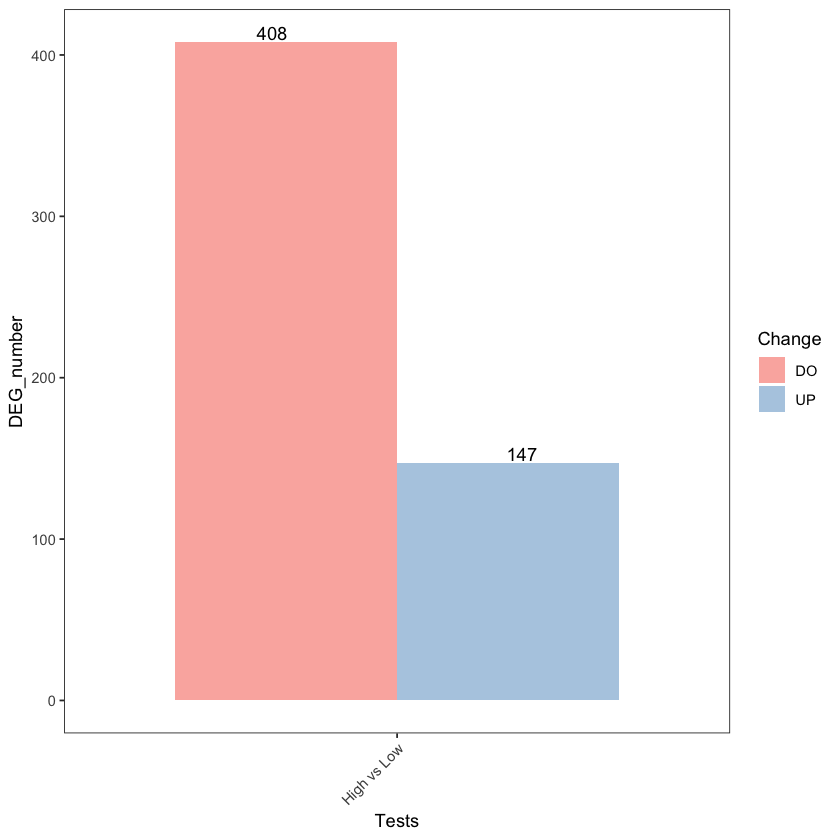

In [ ]:
library(ggplot2)
ggplot(out_final, aes(x = Tests, y = DEG_number, fill = Change)) +
                geom_bar(stat = "identity", position = "dodge", width = 0.8) +
                scale_fill_brewer(palette = "Pastel1") +
                geom_text(aes(label = DEG_number), position = position_dodge2(width = 0.9, preserve = 'single'), vjust = -0.2, hjust = 0.5) +
                theme_bw() +
                theme(panel.grid = element_blank(),
                axis.text.x = element_text(angle = 45, hjust = 1))
#ggsave(plot = p, filename = "./DEG_number_CELL.pdf", width = 10, height = 7)

In [ ]:
head(final_table)

,High vs Low_(log2FC),High vs Low_(pvalue),High vs Low_(padj)
5S_rRNA,0.6211333,0.131880107,0.277039527
5_8S_rRNA,-0.4314752,0.763105651,NA
7SK,-0.4679567,0.411930462,NA
A1BG,0.2796914,0.269992860,0.450370317
A1BG-AS1,0.4497001,0.048846712,0.136620955
A1CF,-1.3011830,0.001126041,0.008274457


In [ ]:
### 选取感兴趣的比较组的结果进行可视化
res <- final_table # 提取差异分析结果
res <- res %>%
       as.data.frame() %>%
       rownames_to_column()
colnames(res) <- c("gene_id", "log2FC", "pvalue", "padj")
dim(res)
head(res)

[1] 54907     4

,gene_id,log2FC,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>
1,5S_rRNA,0.6211333,0.131880107,0.277039527
2,5_8S_rRNA,-0.4314752,0.763105651,NA
3,7SK,-0.4679567,0.411930462,NA
4,A1BG,0.2796914,0.269992860,0.450370317
5,A1BG-AS1,0.4497001,0.048846712,0.136620955
6,A1CF,-1.3011830,0.001126041,0.008274457


In [ ]:
res_sort <- res %>%
            arrange(desc(log2FC)) %>%
            filter(padj!="NA") %>%
            filter(gene_id!="NA") %>%
            distinct(gene_id, .keep_all = TRUE)
dim(res_sort)
res_sort[1:5, ]
write.csv(res_sort, file = "./ICAM1_DEG_sorted.csv")

[1] 35742     4

,gene_id,log2FC,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>
1,AC074389.2,3.999437,2.816932e-03,1.642728e-02
2,NKX2-4,3.515570,1.566751e-02,5.926429e-02
3,AC090515.4,3.462808,1.012288e-14,7.236237e-11
4,PAGE2,3.370035,1.007229e-04,1.348334e-03
5,MUC2,2.893933,1.578917e-10,7.446305e-08


In [ ]:
save(res, res_sort, file = "./ICAM1_DEG.Rdata")

#### 火山图展示差异表达基因

In [ ]:
####** Volcano ====
library(EnhancedVolcano)

In [ ]:
head(res_sort)

,gene_id,log2FC,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>
1,PGA3,5.033810,2.097259e-09,1.973057e-06
2,AC037471.1,4.993677,2.252877e-05,1.188390e-03
3,CT45A1,4.364332,1.483275e-07,4.144235e-05
4,PASD1,4.169226,9.348631e-09,6.550380e-06
5,LINC01854,4.000205,4.394405e-07,8.569090e-05
6,AL137001.2,3.875321,4.046160e-06,3.982578e-04


In [ ]:
p_t = 0.05
FC_t = 0
vol_plot <- res_sort

#### 针对特殊点设置颜色
keyvals <- rep('darkgrey', nrow(vol_plot))
# set the base name/label as 'Mid'
names(keyvals) <- rep('Not-significant', nrow(vol_plot))
# fold change > 1.5 & q-value < 0.05 为高表达
keyvals[which(vol_plot$log2FC > FC_t & vol_plot$padj < p_t)] <- "#BB7A67"
names(keyvals)[which(vol_plot$log2FC  > FC_t & vol_plot$padj < p_t)] <- 'Up-regulated'
# fold change < -1.5 & q-value < 0.05为低表达
keyvals[which(vol_plot$log2FC  < -FC_t & vol_plot$padj < p_t)] <- "#75AEBF"
names(keyvals)[which(vol_plot$log2FC  < -FC_t & vol_plot$padj < p_t)] <- 'Down-regulated'
#keyvals[which(vol_plot$gene_id=="ICAM1")] <- "#7272AA" 
#names(keyvals)[which(vol_plot$gene_id=="ICAM1")] <- "ICAM1"

pdf(file = "./ICAM1_Volcano_DEG.pdf", width = 8, height =6)
EnhancedVolcano(vol_plot, 
                     lab = vol_plot$gene_id,
                     x = 'log2FC',
                     y = 'padj',
                     #selectLab = c("ICAM1"),
                     labSize=4,
                     labFace='bold',#标签字体
                     drawConnectors = TRUE,
                     widthConnectors = 1,
                     boxedLabels = TRUE,
                     xlim = c(-6, 6),
                     ylim = c(0, 10),
                     title = "Differentially expressed genes",
                     subtitle = "High vs Low",
                     caption = NULL,
                     titleLabSize = 18,
                     subtitleLabSize = 14,
                     pCutoff = 0.05,
                     FCcutoff = 0,
                     xlab = bquote(~Log[2]~ 'fold change'),
                     ylab = bquote(~-Log[10]~italic(adj.P)),
                     axisLabSize = 14,
                     pointSize = 1.5,
                     colCustom = keyvals,
                     colAlpha = 4/5,
                     cutoffLineType = 'twodash',
                     cutoffLineWidth = 0.8,
                     legendPosition = 'bottom',
                     legendLabSize = 12,
                     legendIconSize = 5) + coord_flip()
dev.off()

Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Warning message:
"ggrepel: 3364 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


pdf 
  2

#### 热图展示高变基因

In [ ]:
allcompare <- read.table("DEG_geneid_allcomapre.txt", header = T, sep = "\t")

In [ ]:
head(allcompare)

,High.vs.Low_up,High.vs.Low_down
,<chr>,<chr>
1,LIPF,CEACAM5
2,MYH11,S100A8
3,C3,SPRR3
4,MUC6,SPRR1B
5,PGA3,AGR2
6,SYNPO2,CSTB


In [ ]:
top50 <- c(allcompare$High.vs.Low_up[1:25],allcompare$High.vs.Low_down[1:25])

In [ ]:
top50 <- count[top50,]

In [ ]:
### 归一化 CPM:Counts per million & 标准化处理
top50 <- as.data.frame(log2(edgeR::cpm(top50) + 1))

In [ ]:
group <- factor(cli$Group, levels = c("Low","High"))

In [ ]:
group

[1] Low  High Low  High Low  High Low  High Low  Low  High Low  Low  High Low 
[16] High High High Low  Low  High High Low  High High Low  High Low  High Low 
[31] Low  Low  Low  High Low  High High Low  High Low  Low  Low  High Low  Low 
[46] Low  High Low  Low  Low  Low  High High Low  Low  Low  High High High Low 
[61] High Low  High High Low  Low  High High Low  High High High Low  High High
[76] Low  High High High High Low  High High High Low  High Low  Low  Low 
Levels: Low High

In [ ]:
col_fun <- colorRamp2(c(-2, 0, 2),c("#2fa1dd", "white", "#f87669"))

top_annotation <- HeatmapAnnotation(       
        cluster = anno_block(
                             gp = gpar(col="white", fill = c("#91BABB","#CD474A")),
                             labels = c("Low","High"),
                             labels_gp = gpar(col = "black", fontsize = 10, fontfamily = "Times", fontface = "bold")))

pdf(file = "./Heatmap_top50_ICAM1_diff_genes.pdf", width = 6, height =6)

Heatmap(as.matrix(t(scale(t(top50)))),
        border = FALSE,
        show_column_names = FALSE,
        show_row_names = TRUE,
        row_names_gp = gpar(fontsize = 4),
        use_raster = FALSE,
        col = col_fun,
        column_title = NULL,
        top_annotation = top_annotation,
        column_split = factor(group, levels = c("Low","High")),  
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        clustering_distance_rows = "pearson",
        #k = 2,
        show_row_dend = FALSE,
        show_column_dend = FALSE,
        show_heatmap_legend = TRUE,
        heatmap_legend_param = list(
                title = "Scaled gene expression",
                title_gp = gpar(col = "black", cex = 0.75),
                title_position = "leftcenter-rot"),)
dev.off()

pdf 
  2

### **2.3 富集分析**

In [ ]:
load(file = "ICAM1_DEG.Rdata")

In [ ]:
head(res_sort)
dim(res_sort)

,gene_id,log2FC,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>
1,AC074389.2,3.999437,2.816932e-03,1.642728e-02
2,NKX2-4,3.515570,1.566751e-02,5.926429e-02
3,AC090515.4,3.462808,1.012288e-14,7.236237e-11
4,PAGE2,3.370035,1.007229e-04,1.348334e-03
5,MUC2,2.893933,1.578917e-10,7.446305e-08
6,EZHIP,2.878684,4.089632e-03,2.172910e-02


[1] 35742     4

In [ ]:
genes <- res_sort %>% 
         filter(log2FC!="NA") %>% 
         filter(gene_id!="NA") %>% 
         filter(padj!="NA") %>% 
         distinct(gene_id, .keep_all = T)
dim(genes)
genesList <- genes$log2FC
names(genesList) <- genes$gene_id
head(genesList)
tail(genesList)

[1] 35742     4

AC074389.2     NKX2-4 AC090515.4      PAGE2       MUC2      EZHIP 
  3.999437   3.515570   3.462808   3.370035   2.893933   2.878684

APOC3    DEFB4B     LCE3B  PABPC1P6     LCE3C    BPIFB2 
-3.761574 -3.832136 -4.023892 -4.235589 -4.704554 -6.529908

In [ ]:
deg_up <- subset(genes, log2FC >= 1.5 & padj < 0.05)
dim(deg_up)
deg_up[1:5, ]

[1] 147   4

,gene_id,log2FC,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>
1,AC074389.2,3.999437,2.816932e-03,1.642728e-02
3,AC090515.4,3.462808,1.012288e-14,7.236237e-11
4,PAGE2,3.370035,1.007229e-04,1.348334e-03
5,MUC2,2.893933,1.578917e-10,7.446305e-08
6,EZHIP,2.878684,4.089632e-03,2.172910e-02


In [ ]:
deg_dn <- subset(genes, log2FC <= -1.5 & padj < 0.05)
dim(deg_dn)
deg_dn[1:5, ]

[1] 408   4

,gene_id,log2FC,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>
35230,AC004784.1,-1.500276,2.119043e-03,0.013248001
35232,PLA2G4D,-1.500864,4.669698e-05,0.000763145
35233,AC140725.1,-1.501626,3.384046e-03,0.018834962
35234,LINC02886,-1.501953,3.422110e-03,0.019001561
35235,AC109466.1,-1.502478,1.308294e-03,0.009284587


In [ ]:
library(msigdbr)

In [ ]:
geneset1 <- msigdbr(species = "Homo sapiens", category = 'H')
geneset2 <- msigdbr(species = "Homo sapiens", category = "C2", subcategory = "REACTOME")
geneset3 <- msigdbr(species = "Homo sapiens", category = "C2", subcategory = "CP:KEGG")
geneset4 <- msigdbr(species = "Homo sapiens", category = "C5",subcategory = "GO:BP")

all_gene_sets <- rbind(geneset1, geneset2, geneset3, geneset4)
head(all_gene_sets)
length(unique(table(all_gene_sets$gs_name)))
#tail(table(all_gene_sets$gs_name))
#save(all_gene_sets, file = "./MSigDB.Rdata")

In [ ]:
geneset <- rbind(geneset3,geneset4)

In [ ]:
gcSample <- split(geneset4$gene_symbol,
                  geneset4$gs_name)
#names(gcSample)
file <- "./Homo-GOBP-gmts.txt"
gs <- gcSample
write.gmt <- function(gs, file){
  sink(file)
  lapply(names(gs), function(i){
    cat( paste(c(i,'tmp',gs[[i]]),collapse='\t') )
    cat('\n')
  })
  sink()
}
write.gmt(gs, file)

In [ ]:
library(GSEABase)

In [ ]:
file <- "./Homo-GOBP-gmts.txt"
gmts <- clusterProfiler::read.gmt(file)
gsea <- GSEA(genesList, 
            TERM2GENE = gmts,
            minGSSize = 3,
            pvalueCutoff = 0.25,
            verbose = FALSE)
head(gsea)
gsea_results <- gsea@result 
dim(gsea_results)

Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
"For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA."
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
"For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation."


,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GOBP_IMMUNOGLOBULIN_PRODUCTION,GOBP_IMMUNOGLOBULIN_PRODUCTION,GOBP_IMMUNOGLOBULIN_PRODUCTION,210,0.7029774,3.528416,1e-10,2.254268e-09,1.378049e-09,5356,"tags=58%, list=15%, signal=49%",IGLV3-27/IGKV5-2/IGLV2-33/IGKV2-29/IGLV1-44/IGLV10-54/IGLV3-10/IGLV4-69/IGKV1-39/IGKV6D-21/IL6/IGKV3-15/CR1/IGLV8-61/IGLV6-57/IGKV2D-30/IGKV1-9/IGLV2-18/IGKV1D-8/IGKV1-17/IGLV2-8/IGLV3-22/IGKV4-1/IGLV1-47/IGKV2D-29/IGLV5-37/IL2/IGLV3-19/HLA-DQA1/HLA-DQB1/HLA-DRB5/HLA-DOA/IGLV2-23/IGKV1D-42/IGLV1-50/IGKV1D-12/IGKV1-6/HLA-DPA1/HLA-DQA2/IGKV2-40/FOXP3/IGLV4-60/PTPRC/HLA-DRA/IGLV3-21/IGLV1-51/MZB1/IGLV3-16/IGKV3D-7/HLA-DRB1/TNF/SASH3/IGKV1-16/HLA-DMB/IGLV3-32/IGLV3-1/IGLV5-45/IGKV1-5/IL21/IGKV1-12/CD28/IL13/HLA-DPB1/IGKV3D-20/IGKV3D-11/IGKC/TRAV18/IGLV4-3/EPHB2/IGLV11-55/TRAV2/IGKV1-27/IGKV2-28/BTK/IGKV1-8/HLA-DMA/TRAV14DV4/IGLV3-12/CD86/IGLV1-40/IGKV2-24/IGKV3-20/IL5/IL10/TRAV19/CD40/TRAV9-2/FCGR2B/CD22/IGKV3-7/TNFSF13/TNFSF4/IGLV9-49/IGKV1D-39/IGKV1-13/IGKV1D-13/IGKV6D-41/CCR6/IGLV3-25/GAPT/FCRL3/HLA-DQB2/IGKV3D-15/TRAV38-1/IGLV7-46/TRDV2/IGKV2-30/SAMHD1/IGKV1D-17/IL27RA/TP53BP1/TRAV38-2DV8/IGLV2-11/IGLV1-36/VPREB3/TBX21/IGLV5-48/TNFRSF4/PARP3/CD40LG/RIF1
GOBP_REGULATION_OF_B_CELL_ACTIVATION,GOBP_REGULATION_OF_B_CELL_ACTIVATION,GOBP_REGULATION_OF_B_CELL_ACTIVATION,191,0.6860637,3.366595,1e-10,2.254268e-09,1.378049e-09,5356,"tags=56%, list=15%, signal=48%",IGHV1-69D/FOXJ1/IGHV3-33/IGHV3-11/IGHV1-3/IGHM/IGHV3-30/IL6/CR1/IGHV3-53/IGHV4-39/IGHV5-10-1/IL4I1/IGHV1-69/IGHV4-4/IGHV3-7/IL2/IGHG1/NFAM1/IGHV3-13/SLAMF8/IGHV3-73/IGHV3-43/IGHV4-34/NCKAP1L/IGHV4-28/IGLC2/FOXP3/BLK/CD74/PTPRC/IGHV1-45/IGHV3-48/MZB1/IGHV4-31/MEF2C/SASH3/CD300A/TNFSF13B/CD19/MNDA/IGHV2-5/IL21/LAPTM5/TLR4/CD28/IGHV3-21/BANK1/GPR183/IL13/IGHV3-16/IKZF3/IGHV1-18/IGHV3-15/IGKC/EPHB2/TNFRSF13B/INHBA/CD27/TYROBP/IGHV3-66/IL7/SAMSN1/NFATC2/BTK/BCL2/TNFAIP3/CTLA4/INPP5D/IL5/IGHV1OR15-1/IL10/IGHV3-35/IGLL1/IGHV3-23/IGLL5/CD40/IGHV5-51/FCGR2B/CD22/TNFSF13/IGHV1-58/TNFSF4/IGHV7-4-1/SH3KBP1/IGHV2-26/THEMIS2/MMP14/IGHG3/FCRL3/IGHV4-59/BST1/CARD11/TRBC2/IGHG2/IL27RA/IGHV3-74/LYN/TP53BP1/IGHV6-1/IGHV1-24/TRBC1/TBX21/TNFRSF4/PARP3/CD38/RIF1
GOBP_IMMUNE_RESPONSE_REGULATING_CELL_SURFACE_RECEPTOR_SIGNALING_PATHWAY,GOBP_IMMUNE_RESPONSE_REGULATING_CELL_SURFACE_RECEPTOR_SIGNALING_PATHWAY,GOBP_IMMUNE_RESPONSE_REGULATING_CELL_SURFACE_RECEPTOR_SIGNALING_PATHWAY,313,0.6485388,3.365748,1e-10,2.254268e-09,1.378049e-09,4792,"tags=48%, list=13%, signal=42%",IGHV1-69D/IGHV3-33/IGHV3-11/PAK3/IGHV1-3/NR4A3/IGHM/IGHV3-30/LILRB4/CR1/VTCN1/IGHV3-53/IGHV4-39/IGHV5-10-1/LILRB1/IGHV1-69/IGHV4-4/IGHV3-7/IGHG1/HLA-DQB1/NFAM1/IGHV3-13/FPR3/FCN1/IGHV3-73/FCGR3A/IGHV3-43/PDE4B/IGHV4-34/NCKAP1L/IGHV4-28/IGLC2/FOXP3/FYB1/BLK/C5AR1/PTPRC/IGHV1-45/IGHV3-48/FGR/HLA-G/LAX1/FCGR1B/HLA-DRB1/BTN1A1/IGHV4-31/MEF2C/PRKCB/LILRA2/KLRC1/LILRB2/CD300A/GBP1/CD19/C3AR1/MNDA/HCK/IGHV2-5/LCP2/PRAM1/NCR3/PLPP4/LAPTM5/CD28/IGHV3-21/BANK1/CMKLR1/CD200R1/CD79A/LILRA4/SLA2/IGHV3-16/IGHV1-18/HLA-DPB1/PLCL2/ITK/FCER1G/IGHV3-15/IGKC/THEMIS/KLRC3/MS4A1/TYROBP/CR2/IGHV3-66/FYN/FPR1/KLRC4/NFATC2/BTK/BCL2/CLEC6A/CTLA4/MICB/TRAT1/SKAP1/INPP5D/BTN2A2/CD226/UBASH3A/PTPRJ/IGHV1OR15-1/IGHV3-35/IGLL1/PTPN22/THY1/IGHV3-23/IGLL5/SH2D1A/BTN3A1/VAV1/CD40/CD247/IGHV5-51/FCGR2B/CD22/KLHL6/IGHV1-58/TESPA1/IGHV7-4-1/LAT2/CD8A/IGHV2-26/THEMIS2/PDE4D/CD8B/LCK/CLEC4D/IGHG3/ZAP70/KIT/FCRL3/IGHV4-59/CCR7/BTN3A3/CARD11/TRBC2/KLRD1/IGHG2/ABL1/PRKCQ/IGHV3-74/SH2B2/CD79B/LYN/GPLD1/EP300/IGHV6-1/RIPK2/IGHV1-24/BTLA
GOBP_ANTIGEN_RECEPTOR_MEDIATED_SIGNALING_PATHWAY,GOBP_ANTIGEN_RECEPTOR_MEDIATED_SIGNALING_PATHWAY,GOBP_ANTIGEN_RECEPTOR_MEDIATED_SIGNALING_PATHWAY,232,0.6552015,3.343764,1e-10,2.254268e-09,1.378049e-09,4745,"tags=49%, list=13%, signal=43%",IGHV1-69D/IGHV3-33/IGHV3-11/IGHV1-3/IGHM/IGHV3-30/LILRB4/VTCN1/IGHV3-53/IGHV4-39/IGHV5-10-1/IGHV1-69/IGHV4-4/IGHV3-7/IGHG1/HLA-DQB1/NFAM1/IGHV3-13/IGHV3-73/IGHV3-43

[1] 3792   11

In [ ]:
write.csv(gsea_results,file = './gsea_ICAM1_bp.csv', row.names=FALSE)

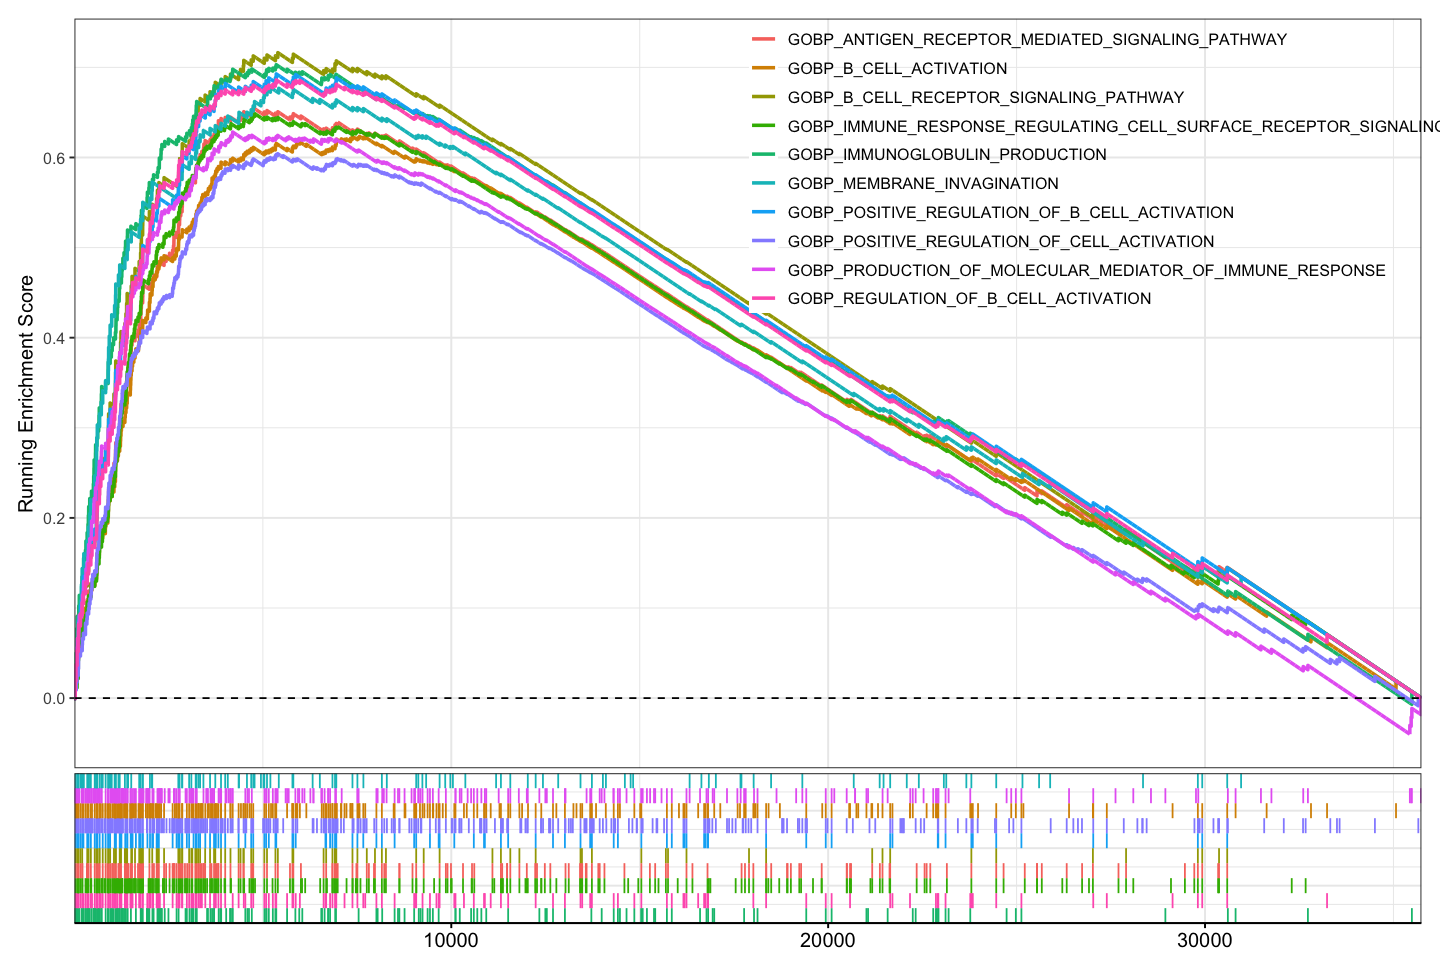

In [ ]:
options(repr.plot.width=12, repr.plot.height=8)
myenrichplot::gseaplot2(gsea, geneSetID = c(1:10), subplots = 1:2, rel_heights=c(1, .2, 1))

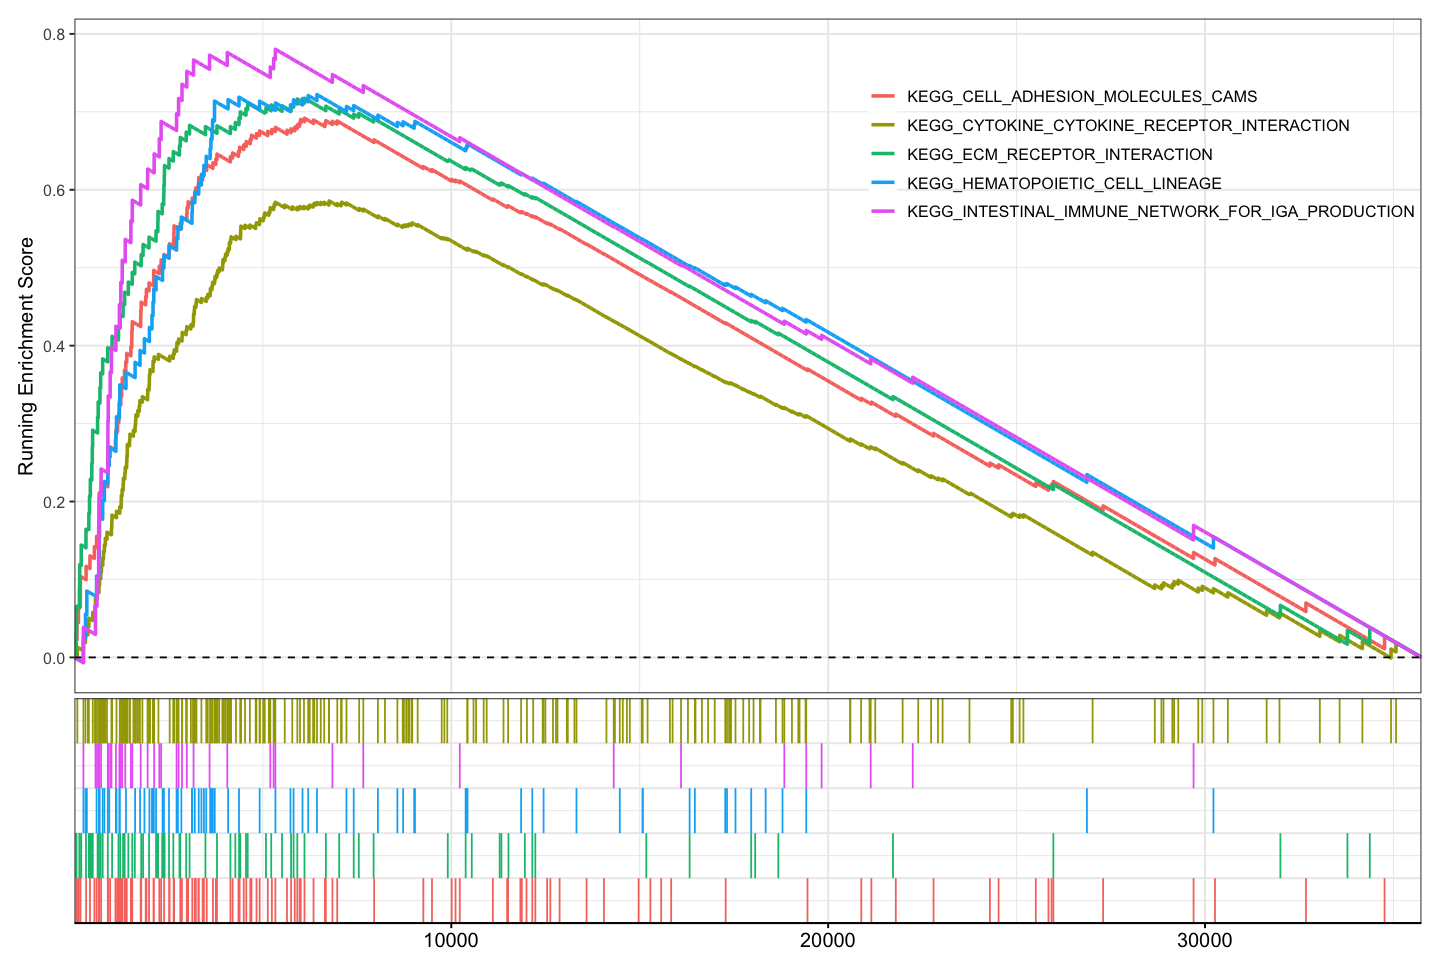

In [ ]:
options(repr.plot.width=12, repr.plot.height=8)
myenrichplot::gseaplot2(gsea, geneSetID = c(10,12,14,16,24), subplots = 1:2)

### **2.4 TME分析**

In [ ]:
group

[1] Low  Low  High High High Low  High High Low  High Low  Low  High Low  Low 
 [16] Low  High High Low  High Low  Low  Low  Low  Low  Low  High Low  Low  High
 [31] High Low  High Low  Low  Low  High Low  High High High Low  High High Low 
 [46] High High High High High High High High High High Low  Low  Low  High High
 [61] High High Low  High Low  Low  Low  Low  High Low  Low  Low  Low  Low  Low 
 [76] Low  High Low  Low  Low  Low  Low  High High High High Low  High High Low 
 [91] High Low  High High Low  Low  Low  Low  Low  Low  High Low  High High High
[106] Low  Low  High High Low  High High High High Low  High High High High High
[121] Low  Low  Low  Low  High Low  High
Levels: High Low

In [ ]:
count <- TSCC_counts_T[apply(TSCC_counts_T, 1, sd)>0.5,]

In [ ]:
dim(count)
head(count)

[1] 42352   127

,TCGA-CR-7401-01A-11R-2016-07,TCGA-CQ-A4CE-01A-11R-A266-07,TCGA-CV-6959-01A-11R-1915-07,TCGA-CV-7104-01A-11R-2016-07,TCGA-DQ-5624-01A-01R-1873-07,TCGA-HD-8635-01A-11R-2403-07,TCGA-CV-6939-01A-11R-1915-07,TCGA-UP-A6WW-01A-12R-A34R-07,TCGA-MT-A67A-01A-11R-A30B-07,TCGA-CR-6488-01A-12R-2081-07,...,TCGA-CV-6433-01A-11R-1686-07,TCGA-CQ-7072-01A-21R-A30B-07,TCGA-CQ-6224-01A-11R-1915-07,TCGA-D6-A4ZB-01A-11R-A24Z-07,TCGA-BA-7269-01A-11R-2016-07,TCGA-C9-A480-01A-12R-A24H-07,TCGA-BB-A6UO-01A-12R-A34R-07,TCGA-CR-7382-01A-11R-2132-07,TCGA-H7-A6C4-01A-11R-A30B-07,TCGA-CN-6019-01A-11R-1686-07
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
5S_rRNA,0,2,0,0,0,0,21,4,1,1,...,11,1,0,0,1,2,1,2,1,1
5_8S_rRNA,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
A1BG,8,2,3,2,6,0,4,4,1,3,...,9,8,8,0,3,2,2,5,5,3
A1BG-AS1,9,11,35,31,86,10,38,24,7,25,...,11,47,25,78,2,30,28,66,76,60
A1CF,1,2,0,0,0,0,0,2,0,2,...,1,0,1,1,1,0,2,1,1,0
A2M,14070,4922,27724,16357,15381,11217,18594,8155,1504,28959,...,3011,18580,51273,2533,4017,3762,5940,75184,7320,29910


In [ ]:
dat <- count2tpm(countMat = count, idType = "Symbol", org="hsa", source = "local" )

>>>--- This is a fuzzy calculation. We recommend that users provide expression matrices with ENSEMBL as row names

>>>--- Using variables (anno_grch38) and gene lengths (eff_length)  built into the IOBR package to perform TPM transformation

>>>--- The gene lengths (eff_length) was estimated by function `getGeneLengthAndGCContent` from EDASeq package with default parameters at 2023-02-10

Warning message in count2tpm(countMat = count, idType = "Symbol", org = "hsa", source = "local"):
">>>--- Omit 946 genes of which length is not available !"


In [ ]:
cibersort <- deconvo_tme(eset = dat, method = "cibersort", arrays = FALSE, perm = 1000 )


>>> Running CIBERSORT



In [ ]:
head(cibersort)

ID,B_cells_naive_CIBERSORT,B_cells_memory_CIBERSORT,Plasma_cells_CIBERSORT,T_cells_CD8_CIBERSORT,T_cells_CD4_naive_CIBERSORT,T_cells_CD4_memory_resting_CIBERSORT,T_cells_CD4_memory_activated_CIBERSORT,T_cells_follicular_helper_CIBERSORT,T_cells_regulatory_(Tregs)_CIBERSORT,...,Macrophages_M2_CIBERSORT,Dendritic_cells_resting_CIBERSORT,Dendritic_cells_activated_CIBERSORT,Mast_cells_resting_CIBERSORT,Mast_cells_activated_CIBERSORT,Eosinophils_CIBERSORT,Neutrophils_CIBERSORT,P-value_CIBERSORT,Correlation_CIBERSORT,RMSE_CIBERSORT
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TCGA-CR-7401-01A-11R-2016-07,0.01464667,0,0.004259753,0.05996177,0,0.17032470,0.005331853,0.02457877,0.081284545,...,0.080781471,0.105113552,0.12244782,0.12740223,0.00000000,0,0.016133026,0.047,0.16147573,1.0221723
TCGA-CQ-A4CE-01A-11R-A266-07,0.02242753,0,0.076187221,0.18160929,0,0.05838767,0.037471244,0.04121241,0.099673017,...,0.040641880,0.047868033,0.08895105,0.01576740,0.00000000,0,0.007757149,0.053,0.14659039,1.0411950
TCGA-CV-6959-01A-11R-1915-07,0.06847162,0,0.065290803,0.01131284,0,0.27592118,0.012794021,0.01173105,0.000000000,...,0.068132984,0.012722890,0.01396435,0.00000000,0.08334909,0,0.031184351,0.032,0.19073846,1.0089383
TCGA-CV-7104-01A-11R-2016-07,0.01820915,0,0.008541057,0.04433165,0,0.33244911,0.000000000,0.04040072,0.005070141,...,0.127378780,0.035605972,0.06637608,0.03242465,0.00000000,0,0.012352410,0.115,0.09302797,1.0539721
TCGA-DQ-5624-01A-01R-1873-07,0.00000000,0,0.113678392,0.01535770,0,0.22114967,0.002353723,0.00000000,0.036922157,...,0.008743253,0.125116963,0.15081809,0.00000000,0.08559397,0,0.003020261,0.040,0.17158234,1.0176464
TCGA-HD-8635-01A-11R-2403-07,0.15836365,0,0.102899971,0.07979028,0,0.18488809,0.000000000,0.01175503,0.008855049,...,0.122053562,0.006304939,0.00000000,0.01328041,0.00000000,0,0.017172118,0.006,0.35431277,0.9390959


In [ ]:
epic <- deconvo_tme(eset = dat, method = "epic", arrays = FALSE)


>>> Running EPIC

Warning message in IOBR::EPIC(bulk = eset, reference = ref, mRNA_cell = NULL, scaleExprs = TRUE):
"The optimization didn't fully converge for some samples:
TCGA-HD-7831-01A-11R-2132-07; TCGA-CV-6436-01A-11R-1686-07; TCGA-CN-6016-01A-11R-1686-07; TCGA-CQ-6224-01A-11R-1915-07; TCGA-CN-6019-01A-11R-1686-07
 - check fit.gof for the convergeCode and convergeMessage"
Warning message in IOBR::EPIC(bulk = eset, reference = ref, mRNA_cell = NULL, scaleExprs = TRUE):
"mRNA_cell value unknown for some cell types: CAFs, Endothelial - using the default value of 0.4 for these but this might bias the true cell proportions from all cell types."


In [ ]:
head(epic)

ID,Bcells_EPIC,CAFs_EPIC,CD4_Tcells_EPIC,CD8_Tcells_EPIC,Endothelial_EPIC,Macrophages_EPIC,NKcells_EPIC,otherCells_EPIC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TCGA-CR-7401-01A-11R-2016-07,1.737408e-06,0.47217193,0.02775060,2.604132e-06,0.03656124,0.005214649,9.143629e-06,0.4582881
TCGA-CQ-A4CE-01A-11R-A266-07,2.056627e-03,0.02151213,0.01721708,3.865235e-02,0.02936473,0.003008471,3.201815e-04,0.8878684
TCGA-CV-6959-01A-11R-1915-07,5.567015e-03,0.08948733,0.13078463,5.402722e-07,0.05189739,0.015509431,4.536102e-09,0.7067537
TCGA-CV-7104-01A-11R-2016-07,7.247096e-06,0.18606977,0.12730209,9.942482e-08,0.04326017,0.022826501,1.188621e-03,0.6193455
TCGA-DQ-5624-01A-01R-1873-07,4.780404e-03,0.16568778,0.15821871,1.496322e-03,0.03192466,0.007053110,6.607006e-08,0.6308389
TCGA-HD-8635-01A-11R-2403-07,3.285405e-03,0.09757384,0.11261960,7.647628e-03,0.03115290,0.009260425,7.365594e-09,0.7384602


In [ ]:
xcell <- deconvo_tme(eset = dat, method = "xcell", arrays = FALSE)


>>> Running xCell



[1] "Num. of genes: 10466"


Warning message:
"Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva')."


Estimating ssGSEA scores for 489 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



In [ ]:
head(xcell)

ID,Adipocytes_xCell,Astrocytes_xCell,B-cells_xCell,Basophils_xCell,CD4+_T-cells_xCell,CD4+_Tcm_xCell,CD4+_Tem_xCell,CD4+_memory_T-cells_xCell,CD4+_naive_T-cells_xCell,...,cDC_xCell,iDC_xCell,ly_Endothelial_cells_xCell,mv_Endothelial_cells_xCell,naive_B-cells_xCell,pDC_xCell,pro_B-cells_xCell,ImmuneScore_xCell,StromaScore_xCell,MicroenvironmentScore_xCell
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TCGA-CR-7401-01A-11R-2016-07,3.678721e-04,6.481318e-02,0.00000000,1.383811e-19,0.004821646,0.06234733,0.026211153,0.0002965385,0.000000e+00,...,0.16320457,0.11117744,0.022915044,0.027512640,4.060270e-19,0.016906668,3.028435e-18,0.05459403,0.049304485,0.10389851
TCGA-CQ-A4CE-01A-11R-A266-07,0.000000e+00,5.121121e-18,0.02339331,2.772248e-02,0.010509992,0.09806939,0.031234410,0.0008850713,7.405359e-20,...,0.04786881,0.03062144,0.012561502,0.022384904,0.000000e+00,0.029380592,6.746709e-03,0.10196103,0.018656924,0.12061795
TCGA-CV-6959-01A-11R-1915-07,0.000000e+00,0.000000e+00,0.02060138,5.654884e-02,0.000000000,0.06188813,0.020149818,0.0031947660,3.246886e-18,...,0.05764047,0.28204470,0.028447283,0.032852156,2.193423e-03,0.029807833,1.569060e-02,0.07619082,0.039968566,0.11615939
TCGA-CV-7104-01A-11R-2016-07,1.290065e-19,1.621194e-02,0.02098408,2.815833e-02,0.008122210,0.07183887,0.021495479,0.0000000000,0.000000e+00,...,0.14915667,0.24301955,0.005368634,0.002764590,0.000000e+00,0.059922775,2.891641e-03,0.12824823,0.008802993,0.13705122
TCGA-DQ-5624-01A-01R-1873-07,0.000000e+00,1.211514e-18,0.01565465,2.667679e-02,0.010737324,0.07788920,0.026955424,0.0019370331,0.000000e+00,...,0.25749917,0.13469490,0.007861618,0.001655983,2.444922e-18,0.000411225,4.259407e-18,0.07459693,0.027655941,0.10225288
TCGA-HD-8635-01A-11R-2403-07,6.717263e-02,0.000000e+00,0.01009341,3.373516e-02,0.000000000,0.03981859,0.007990371,0.0000000000,4.069008e-18,...,0.03965460,0.36969582,0.002188802,0.006411161,1.483028e-03,0.009363523,4.325410e-03,0.04843245,0.039805426,0.08823788


In [ ]:
estimate <- deconvo_tme(eset = dat, method = "estimate")


>>> Running ESTIMATE



[1] "Merged dataset includes 9834 genes (578 mismatched)."
[1] "1 gene set: StromalSignature  overlap= 136"
[1] "2 gene set: ImmuneSignature  overlap= 139"


In [ ]:
head(estimate)

ID,StromalScore_estimate,ImmuneScore_estimate,ESTIMATEScore_estimate,TumorPurity_estimate
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
TCGA-CR-7401-01A-11R-2016-07,511.0975,746.9914,1258.0890,0.7040867
TCGA-CQ-A4CE-01A-11R-A266-07,-681.2999,746.8609,65.5610,0.8169979
TCGA-CV-6959-01A-11R-1915-07,123.7636,1111.7438,1235.5074,0.7064367
TCGA-CV-7104-01A-11R-2016-07,433.6485,1273.0819,1706.7304,0.6558295
TCGA-DQ-5624-01A-01R-1873-07,142.4996,757.1091,899.6088,0.7404617
TCGA-HD-8635-01A-11R-2403-07,-171.5687,704.0278,532.4591,0.7755907


In [ ]:
tme_combine  <-cibersort %>% 
  inner_join(.,xcell,by     = "ID") %>%
  inner_join(.,epic,by      = "ID") %>% 
  inner_join(.,estimate,by  = "ID")
dim(tme_combine)

[1] 127 105

In [ ]:
ICAM1 <- inner_join(ICAM1_OS, tme_combine, by = c("Sample" = "ID"))

In [ ]:
head(ICAM1)
dim(ICAM1)

,Sample,ICAM1,patient,vital_status,days_to_death,days_to_last_follow_up,days,time,Status,Group,...,CD4_Tcells_EPIC,CD8_Tcells_EPIC,Endothelial_EPIC,Macrophages_EPIC,NKcells_EPIC,otherCells_EPIC,StromalScore_estimate,ImmuneScore_estimate,ESTIMATEScore_estimate,TumorPurity_estimate
,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TCGA-CR-7401-01A-11R-2016-07,10.55938,TCGA-CR-7401,Alive,NA,1077,NA,NA,0,Low,...,0.02775060,2.604132e-06,0.03656124,0.005214649,9.143629e-06,0.4582881,511.0975,746.9914,1258.0890,0.7040867
2,TCGA-CQ-A4CE-01A-11R-A266-07,10.24555,TCGA-CQ-A4CE,Alive,NA,897,NA,NA,0,Low,...,0.01721708,3.865235e-02,0.02936473,0.003008471,3.201815e-04,0.8878684,-681.2999,746.8609,65.5610,0.8169979
3,TCGA-CV-6959-01A-11R-1915-07,13.41521,TCGA-CV-6959,Dead,256,NA,NA,NA,1,High,...,0.13078463,5.402722e-07,0.05189739,0.015509431,4.536102e-09,0.7067537,123.7636,1111.7438,1235.5074,0.7064367
4,TCGA-CV-7104-01A-11R-2016-07,13.53284,TCGA-CV-7104,Dead,393,NA,NA,NA,1,High,...,0.12730209,9.942482e-08,0.04326017,0.022826501,1.188621e-03,0.6193455,433.6485,1273.0819,1706.7304,0.6558295
5,TCGA-DQ-5624-01A-01R-1873-07,12.04610,TCGA-DQ-5624,Alive,NA,1778,NA,NA,0,High,...,0.15821871,1.496322e-03,0.03192466,0.007053110,6.607006e-08,0.6308389,142.4996,757.1091,899.6088,0.7404617
6,TCGA-HD-8635-01A-11R-2403-07,11.04508,TCGA-HD-8635,Alive,NA,695,NA,NA,0,Low,...,0.11261960,7.647628e-03,0.03115290,0.009260425,7.365594e-09,0.7384602,-171.5687,704.0278,532.4591,0.7755907


[1] 127 114

In [ ]:
save(cibersort, epic, estimate, xcell, tme_combine, ICAM1, file="./ICAM1_TME.Rdata")

In [ ]:
write.csv(ICAM1, file="./ICAM1.csv", quote=FALSE, row.names =FALSE)

In [ ]:
load(file = "./ICAM1_TME.Rdata")

In [ ]:
ICAM1 <- read.csv("./ICAM1.csv")

#### **estimate**

In [ ]:
Group <- ICAM1[,c(1,10)]

In [ ]:
estimate <- inner_join(Group, estimate, by = c("Sample" = "ID"))

In [ ]:
head(estimate)

,Sample,Group,StromalScore_estimate,ImmuneScore_estimate,ESTIMATEScore_estimate,TumorPurity_estimate
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,TCGA-CR-7401-01A-11R-2016-07,Low,511.0975,746.9914,1258.0890,0.7040867
2,TCGA-CQ-A4CE-01A-11R-A266-07,Low,-681.2999,746.8609,65.5610,0.8169979
3,TCGA-CV-6959-01A-11R-1915-07,High,123.7636,1111.7438,1235.5074,0.7064367
4,TCGA-CV-7104-01A-11R-2016-07,High,433.6485,1273.0819,1706.7304,0.6558295
5,TCGA-DQ-5624-01A-01R-1873-07,High,142.4996,757.1091,899.6088,0.7404617
6,TCGA-HD-8635-01A-11R-2403-07,Low,-171.5687,704.0278,532.4591,0.7755907


In [ ]:
estimate <- estimate[,-5]

In [ ]:
colnames(estimate) <- c("Sample","Group","Stromal score","Immune score", "Tumor Purity") #, "ESTIMATE score"

In [ ]:
plot_data <- melt(estimate,
                  id.vars = c("Sample","Group"),
                  measure.vars = c("Stromal score","Immune score"),
                  variable.name = "Type",
                  value.name = "Score")
plot_data$Score <- as.numeric(plot_data$Score)

Warning message:
"The melt generic in data.table has been passed a data.frame and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is superseded and is no longer actively developed, and this redirection is now deprecated. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace, i.e. reshape2::melt(estimate). In the next version, this warning will become an error."


In [ ]:
plot_data$Group <- factor(plot_data$Group, levels = c("Low", "High"))
plot_data$Type <- factor(plot_data$Type, levels = c("Stromal score","Immune score"))

In [ ]:
head(plot_data)

,Sample,Group,Type,Score
,<chr>,<fct>,<fct>,<dbl>
1,TCGA-CR-7401-01A-11R-2016-07,Low,Stromal score,511.0975
2,TCGA-CQ-A4CE-01A-11R-A266-07,Low,Stromal score,-681.2999
3,TCGA-CV-6959-01A-11R-1915-07,High,Stromal score,123.7636
4,TCGA-CV-7104-01A-11R-2016-07,High,Stromal score,433.6485
5,TCGA-DQ-5624-01A-01R-1873-07,High,Stromal score,142.4996
6,TCGA-HD-8635-01A-11R-2403-07,Low,Stromal score,-171.5687


In [ ]:
compare_means(StromalScore_estimate ~ Group, data = ICAM1, method = "t.test")

.y.,group1,group2,p,p.adj,p.format,p.signif,method
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
StromalScore_estimate,Low,High,1.206654e-05,1.2e-05,1.2e-05,****,T-test


In [ ]:
t.test(StromalScore_estimate ~ Group, data = ICAM1)


	Welch Two Sample t-test

data:  StromalScore_estimate by Group
t = 4.5616, df = 123.42, p-value = 1.207e-05
alternative hypothesis: true difference in means between group High and group Low is not equal to 0
95 percent confidence interval:
 329.1067 833.6462
sample estimates:
mean in group High  mean in group Low 
          369.6086          -211.7678 


In [ ]:
compare_means(ImmuneScore_estimate ~ Group, data = ICAM1, method = "t.test")

.y.,group1,group2,p,p.adj,p.format,p.signif,method
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
ImmuneScore_estimate,Low,High,0.0001169032,0.00012,0.00012,***,T-test


In [ ]:
t.test(ImmuneScore_estimate ~ Group, data = ICAM1)


	Welch Two Sample t-test

data:  ImmuneScore_estimate by Group
t = 3.9785, df = 124.63, p-value = 0.0001169
alternative hypothesis: true difference in means between group High and group Low is not equal to 0
95 percent confidence interval:
 253.5784 755.6277
sample estimates:
mean in group High  mean in group Low 
         1206.4246           701.8216 


Warning message:
"No shared levels found between `names(values)` of the manual scale and the
data's fill values."
Warning message:
"No shared levels found between `names(values)` of the manual scale and the
data's fill values."


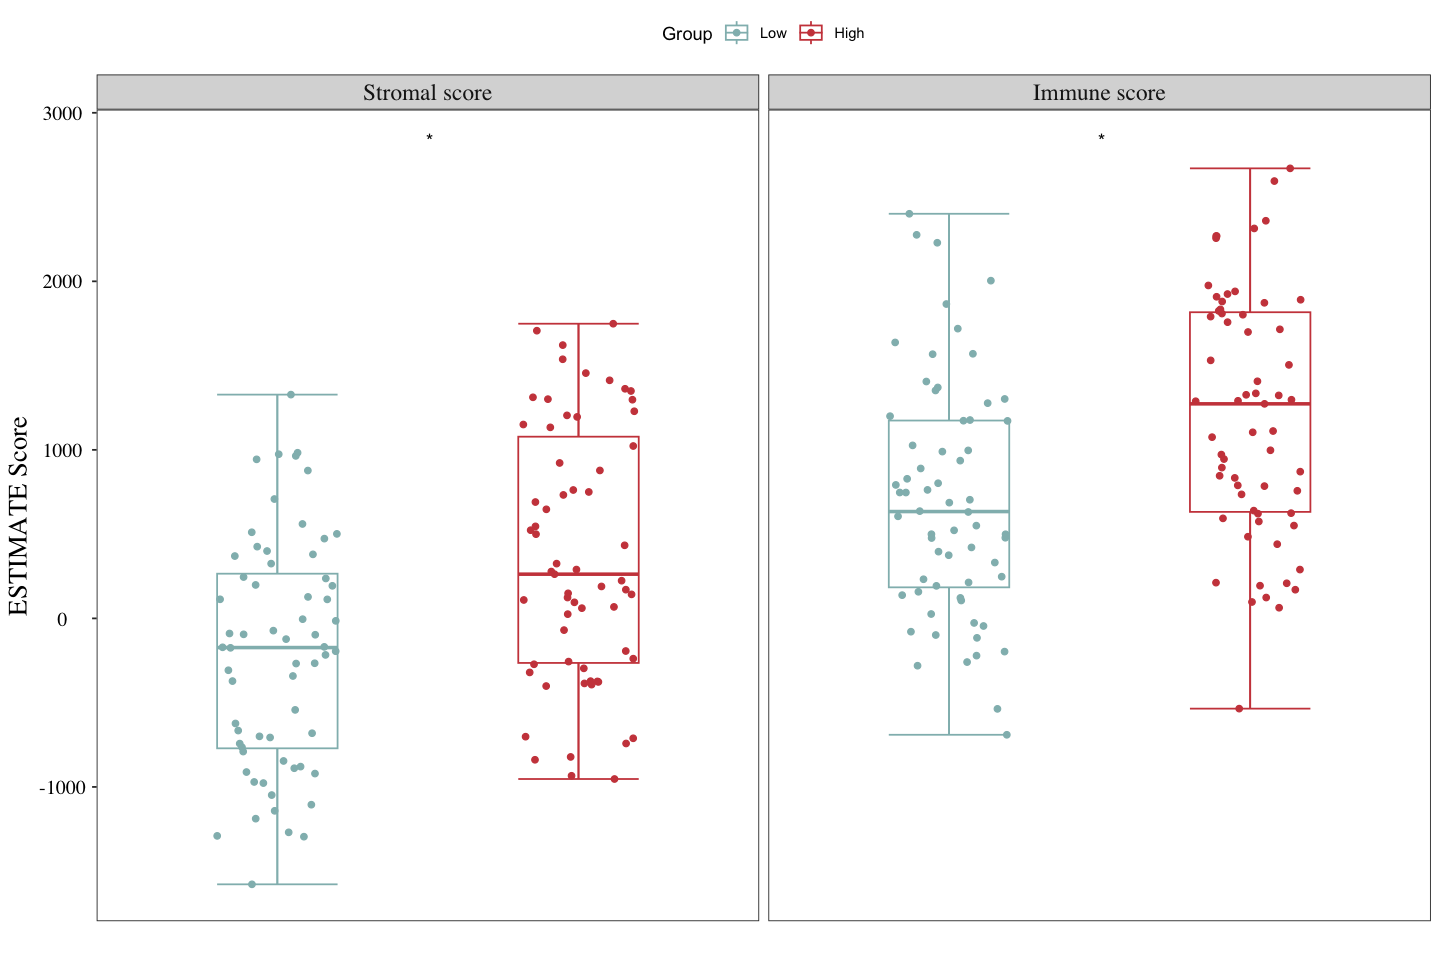

In [ ]:
# Box plot facetted by "Dataset"
p <- ggboxplot(plot_data, x = "Group", y = "Score", #fill = "Group",
               color = "Group", palette = c("Low"="#91BABB", "High"="#CD474A"),
               add = "jitter", bxp.errorbar=T, width = 0.4, line.color = "black", line.size = 0.1,
               facet.by = "Type", short.panel.labs = TRUE) + #
  stat_compare_means(aes(group=Group), method = "t.test",label = "p.signif", label.x = 1.5, label.y = 2800,
                        symnum.args=list(cutpoints = c(0, 0.05, 1), symbols = c("*", " "))) +
  xlab(label = ' ') +
  ylab(label = 'ESTIMATE Score') +
  theme_bw()+
  theme(legend.position = "top",
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        #axis.text.x = element_text(vjust = 0.5, hjust=0.5, family = "Times", colour = "black", size = 12),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.text.y = element_text(vjust = 0.5, hjust=0.5, family = "Times", colour = "black", size = 12),
        axis.title.x = element_text(vjust = 2, hjust=0.5, family = "Times", colour = "black", size = 14,face = 'plain'),
        axis.title.y = element_text(vjust = 1, hjust=0.5, family = "Times", colour = "black", size = 16,face = 'plain'),
        strip.text.x = element_text(size = 14, family = "Times", face = "plain"),
        )
p
ggsave(filename="./TME_Estimate.pdf",plot=p, width = 6,height = 6)

In [ ]:
head(estimate)

,Sample,Group,Stromal score,Immune score,Tumor Purity
,<chr>,<fct>,<dbl>,<dbl>,<dbl>
1,TCGA-CR-7401-01A-11R-2016-07,Low,511.0975,746.9914,0.7040867
2,TCGA-CQ-A4CE-01A-11R-A266-07,Low,-681.2999,746.8609,0.8169979
3,TCGA-CV-6959-01A-11R-1915-07,High,123.7636,1111.7438,0.7064367
4,TCGA-CV-7104-01A-11R-2016-07,High,433.6485,1273.0819,0.6558295
5,TCGA-DQ-5624-01A-01R-1873-07,High,142.4996,757.1091,0.7404617
6,TCGA-HD-8635-01A-11R-2403-07,Low,-171.5687,704.0278,0.7755907


In [ ]:
estimate$Group <- factor(estimate$Group, levels = c("Low", "High"))

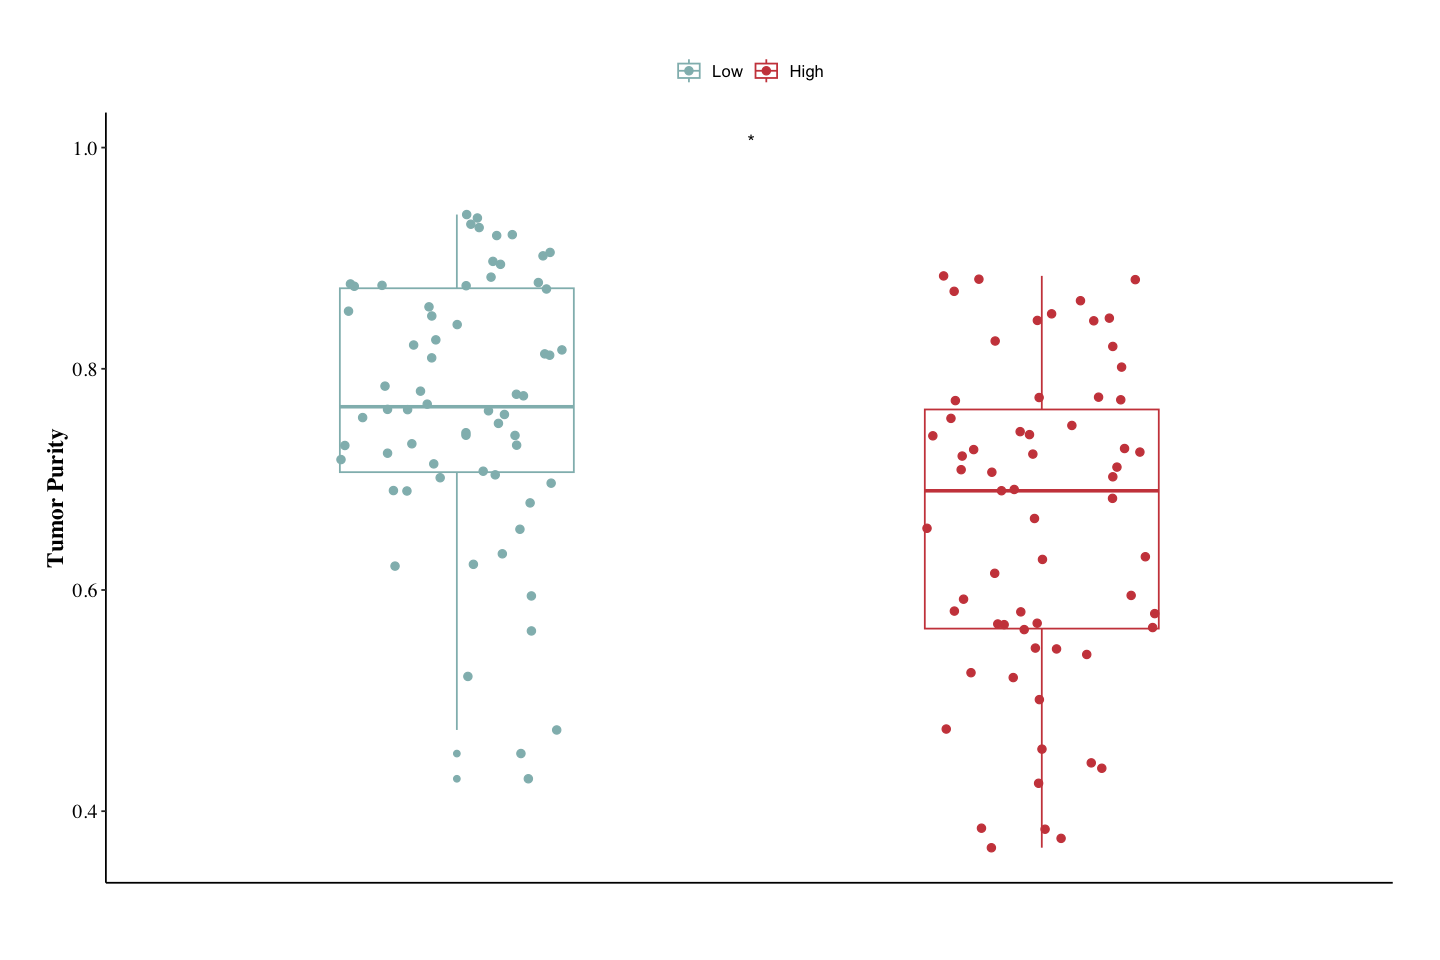

In [ ]:
p1 <- ggplot(estimate, aes(x = Group, y = `Tumor Purity`)) +
        #geom_violin(aes(fill = Group, colour = Group), alpha = 0.8) + 
        geom_boxplot(aes(colour = Group), width = 0.4) + # 添加箱线图图层
        geom_jitter(aes(fill=Group, colour = Group), width =0.2, shape = 21, size=2)+
        labs(x = " ", y = 'Tumor Purity') +
        scale_fill_manual(values = c("Low"="#91BABB", "High"="#CD474A"))+ 
        scale_color_manual(values = c("Low"="#91BABB", "High"="#CD474A"))+ 
        theme_bw() +
        stat_compare_means(aes(group=Group), method = "t.test",label = "p.signif", label.x = 1.5, label.y = 1,
                      symnum.args=list(cutpoints = c(0, 0.05, 1), symbols = c("*", " "))) +
        xlab(label = ' ') +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            panel.border = element_blank(),
            axis.line.x = element_line(color="black"), 
            axis.line.y = element_line(color="black"),
            #axis.text.x = element_text(vjust = 0.5, hjust=0.5, family = "Times", colour = "black", size = 12),
            axis.text.x = element_blank(),
            axis.ticks.x = element_blank(),
            axis.text.y = element_text(vjust = 0.5, hjust=0.5, family = "Times", colour = "black", size = 12),
            axis.title.x = element_text(vjust = 0.5, hjust=0.5, family = "Times", colour = "black", size = 14,face = 'bold'),
            axis.title.y = element_text(vjust = 1, hjust=0.5, family = "Times", colour = "black", size = 14,face = 'bold'),
          plot.margin = unit(c(1, 1, 1, 1), units = , "cm"),
          legend.text = element_text(size = 10),          
          legend.title = element_blank(),                              
          legend.position = "top", 
          legend.key = element_blank(),
          legend.background = element_rect(color = "black", 
                                           fill = "transparent", 
                                           size = 4, linetype = "blank"))
p1
ggsave(filename="./Estimate_TumorPurity.pdf",plot=p1, width = 4,height = 6)

#### **cibersort**

In [ ]:
cibersort <- inner_join(Group, cibersort, by = c("Sample" = "ID"))

In [ ]:
head(cibersort)
dim(cibersort)

,Sample,Group,B_cells_naive_CIBERSORT,B_cells_memory_CIBERSORT,Plasma_cells_CIBERSORT,T_cells_CD8_CIBERSORT,T_cells_CD4_naive_CIBERSORT,T_cells_CD4_memory_resting_CIBERSORT,T_cells_CD4_memory_activated_CIBERSORT,T_cells_follicular_helper_CIBERSORT,...,Macrophages_M2_CIBERSORT,Dendritic_cells_resting_CIBERSORT,Dendritic_cells_activated_CIBERSORT,Mast_cells_resting_CIBERSORT,Mast_cells_activated_CIBERSORT,Eosinophils_CIBERSORT,Neutrophils_CIBERSORT,P-value_CIBERSORT,Correlation_CIBERSORT,RMSE_CIBERSORT
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TCGA-CR-7401-01A-11R-2016-07,Low,0.01464667,0,0.004259753,0.05996177,0,0.17032470,0.005331853,0.02457877,...,0.080781471,0.105113552,0.12244782,0.12740223,0.00000000,0,0.016133026,0.047,0.16147573,1.0221723
2,TCGA-CQ-A4CE-01A-11R-A266-07,Low,0.02242753,0,0.076187221,0.18160929,0,0.05838767,0.037471244,0.04121241,...,0.040641880,0.047868033,0.08895105,0.01576740,0.00000000,0,0.007757149,0.053,0.14659039,1.0411950
3,TCGA-CV-6959-01A-11R-1915-07,High,0.06847162,0,0.065290803,0.01131284,0,0.27592118,0.012794021,0.01173105,...,0.068132984,0.012722890,0.01396435,0.00000000,0.08334909,0,0.031184351,0.032,0.19073846,1.0089383
4,TCGA-CV-7104-01A-11R-2016-07,High,0.01820915,0,0.008541057,0.04433165,0,0.33244911,0.000000000,0.04040072,...,0.127378780,0.035605972,0.06637608,0.03242465,0.00000000,0,0.012352410,0.115,0.09302797,1.0539721
5,TCGA-DQ-5624-01A-01R-1873-07,High,0.00000000,0,0.113678392,0.01535770,0,0.22114967,0.002353723,0.00000000,...,0.008743253,0.125116963,0.15081809,0.00000000,0.08559397,0,0.003020261,0.040,0.17158234,1.0176464
6,TCGA-HD-8635-01A-11R-2403-07,Low,0.15836365,0,0.102899971,0.07979028,0,0.18488809,0.000000000,0.01175503,...,0.122053562,0.006304939,0.00000000,0.01328041,0.00000000,0,0.017172118,0.006,0.35431277,0.9390959


[1] 127  27

In [ ]:
# 数据粗处理
TME_data <- cibersort[,c(1:24)]

In [ ]:
colnames(TME_data)

[1] "Sample"                                
 [2] "Group"                                 
 [3] "B_cells_naive_CIBERSORT"               
 [4] "B_cells_memory_CIBERSORT"              
 [5] "Plasma_cells_CIBERSORT"                
 [6] "T_cells_CD8_CIBERSORT"                 
 [7] "T_cells_CD4_naive_CIBERSORT"           
 [8] "T_cells_CD4_memory_resting_CIBERSORT"  
 [9] "T_cells_CD4_memory_activated_CIBERSORT"
[10] "T_cells_follicular_helper_CIBERSORT"   
[11] "T_cells_regulatory_(Tregs)_CIBERSORT"  
[12] "T_cells_gamma_delta_CIBERSORT"         
[13] "NK_cells_resting_CIBERSORT"            
[14] "NK_cells_activated_CIBERSORT"          
[15] "Monocytes_CIBERSORT"                   
[16] "Macrophages_M0_CIBERSORT"              
[17] "Macrophages_M1_CIBERSORT"              
[18] "Macrophages_M2_CIBERSORT"              
[19] "Dendritic_cells_resting_CIBERSORT"     
[20] "Dendritic_cells_activated_CIBERSORT"   
[21] "Mast_cells_resting_CIBERSORT"          
[22] "Mast_cells_activated_CIBERSORT"        
[23] "Eosinophils_CIBERSORT"                 
[24] "Neutrophils_CIBERSORT"

In [ ]:
colnames(TME_data) <- c("Sample","Group",
    'B cells naive','B cells memory','Plasma cells',
    'T cells CD8','T cells CD4 naive','T cells CD4 memory resting','T cells CD4 memory activated','T cells follicular helper','Tregs','T cells gamma delta',
    'NK cells resting','NK cells activated',
    'Monocytes','Macrophages M0','Macrophages M1','Macrophages M2',
    'Dendritic cells resting','Dendritic cells activated','Mast cells resting','Mast cells activated','Eosinophils','Neutrophils')

In [ ]:
# 融合数据
TME_New = reshape2::melt(TME_data)
colnames(TME_New)=c("Sample","Group","Celltype","Composition")  #设置行名
head(TME_New)

Using Sample, Group as id variables



,Sample,Group,Celltype,Composition
,<chr>,<chr>,<fct>,<dbl>
1,TCGA-CR-7401-01A-11R-2016-07,Low,B cells naive,0.01464667
2,TCGA-CQ-A4CE-01A-11R-A266-07,Low,B cells naive,0.02242753
3,TCGA-CV-6959-01A-11R-1915-07,High,B cells naive,0.06847162
4,TCGA-CV-7104-01A-11R-2016-07,High,B cells naive,0.01820915
5,TCGA-DQ-5624-01A-01R-1873-07,High,B cells naive,0.00000000
6,TCGA-HD-8635-01A-11R-2403-07,Low,B cells naive,0.15836365


In [ ]:
TME_New$Group <- factor(TME_New$Group, levels = c("Low", "High"))

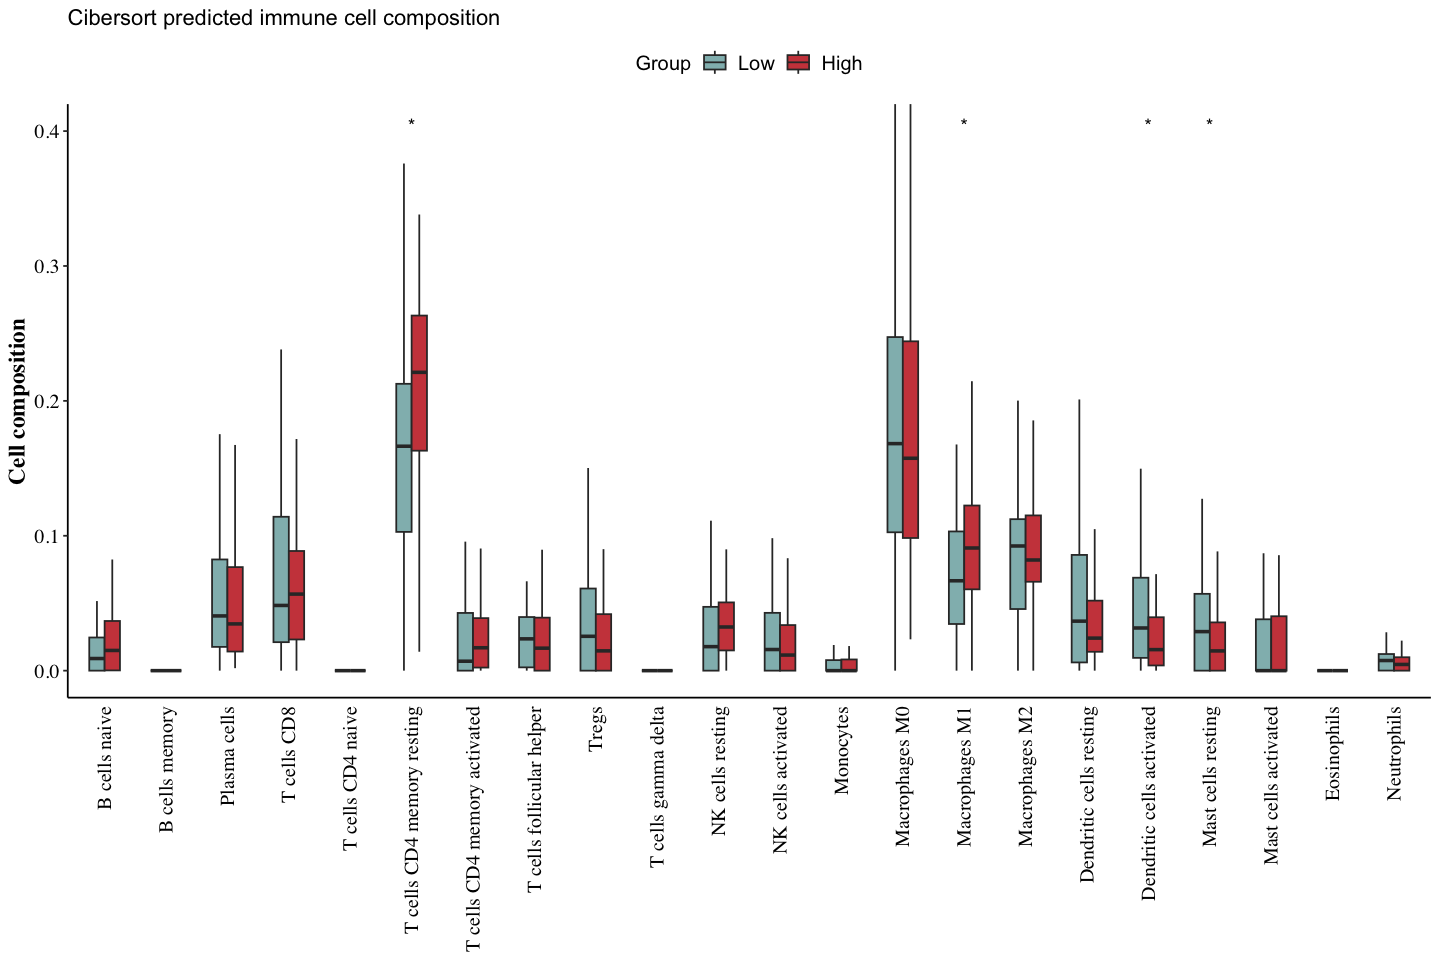

In [ ]:
box_TME <- ggplot(TME_New, aes(x = Celltype, y = Composition))+ 
  labs(y="Cell composition",x= NULL,title = "Cibersort predicted immune cell composition")+  
  geom_boxplot(aes(fill = Group),position=position_dodge(0.5),width=0.5,outlier.alpha = 0)+ 
  scale_fill_manual(values = c("Low"="#91BABB", "High"="#CD474A"))+
  theme_classic() + mytheme + 
  coord_cartesian(ylim = c(0,0.4)) +
  stat_compare_means(aes(group =  Group),
                     label = "p.signif",
                     method = "t.test",
                     hide.ns = T,label.y = 0.4,
                     symnum.args=list(cutpoints = c(0, 0.05, 1), symbols = c("*", " ")))

box_TME
ggsave("./TSCC_CIBERSORT.pdf",box_TME,height=15,width=25,unit="cm")

In [ ]:
TME_new = TME_New %>% 
  group_by(Sample,Group,Celltype) %>%
  summarize(Sum = sum(Composition)) %>%
  data.frame()

`summarise()` has grouped output by 'Sample', 'Group'. You can override using
the `.groups` argument.


In [ ]:
head(TME_new)

,Sample,Group,Celltype,Sum
,<chr>,<fct>,<fct>,<dbl>
1,TCGA-4P-AA8J-01A-11R-A39I-07,Low,B cells naive,0.04064687
2,TCGA-4P-AA8J-01A-11R-A39I-07,Low,B cells memory,0.00000000
3,TCGA-4P-AA8J-01A-11R-A39I-07,Low,Plasma cells,0.24101155
4,TCGA-4P-AA8J-01A-11R-A39I-07,Low,T cells CD8,0.03686777
5,TCGA-4P-AA8J-01A-11R-A39I-07,Low,T cells CD4 naive,0.00000000
6,TCGA-4P-AA8J-01A-11R-A39I-07,Low,T cells CD4 memory resting,0.16839252


In [ ]:
TME_new$Group <- factor(TME_new$Group, levels = c("Low", "High"))

In [ ]:
mytheme <- theme(
        axis.text.x = element_text(vjust = 0.5, hjust=1, family = "Times", colour = "black", size = 12,angle = 90),
        axis.ticks.x = element_blank(),
        axis.text.y = element_text(vjust = 0.5, hjust=0.5, family = "Times", colour = "black", size = 12),
        axis.title.x = element_text(vjust = 2, hjust=0.5, family = "Times", colour = "black", size = 14,face = 'bold'),
        axis.title.y = element_text(vjust = 1, hjust=0.5, family = "Times", colour = "black", size = 14,face = 'bold'),
        strip.text.x = element_text(size = 12, family = "Times", face = "plain"),
        panel.grid.minor = element_blank(),
        panel.grid.major = element_blank(),
        #strip.background = element_blank(),
        legend.position = "top",
        legend.text = element_text(size= 12),
        legend.title= element_text(size= 12)
)

Warning message:
"Computation failed in `stat_compare_means()`.
Caused by error in `data.frame()`:
! arguments imply differing number of rows: 0, 1"
Warning message:
"Computation failed in `stat_compare_means()`.
Caused by error in `data.frame()`:
! arguments imply differing number of rows: 0, 1"
Warning message:
"Computation failed in `stat_compare_means()`.
Caused by error in `data.frame()`:
! arguments imply differing number of rows: 0, 1"
Warning message:
"Computation failed in `stat_compare_means()`.
Caused by error in `data.frame()`:
! arguments imply differing number of rows: 0, 1"


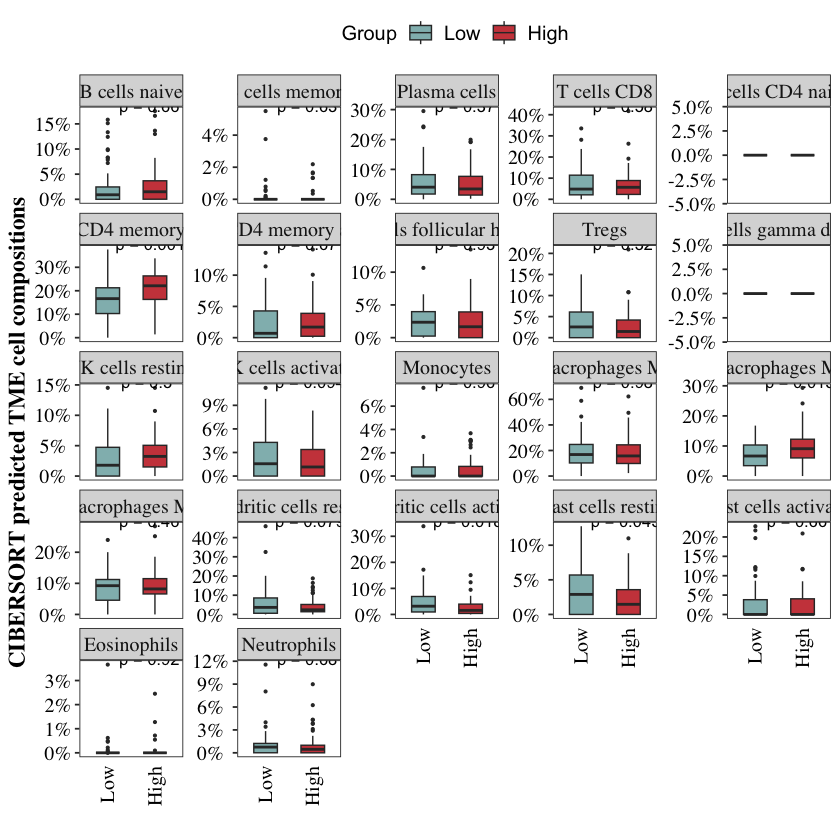

In [ ]:
box <- ggplot(TME_new, aes(x = Group, y = Sum))+ 
  geom_boxplot(aes(fill = Group),position=position_dodge(0.5),width=0.5,size=0.4,
               outlier.alpha = 1, outlier.size = 0.5)+ 
  theme_bw() + mytheme + 
  labs(x=" ",y = "CIBERSORT predicted TME cell compositions") +
  scale_fill_manual(values = c("Low"="#91BABB", "High"="#CD474A"))+ 
  scale_y_continuous(labels = scales::percent)+
  facet_wrap(~ Celltype, scales = "free_y", ncol = 5) + 
  stat_compare_means(aes(group =  Group),
                     label = "p.format",
                     method = "t.test",
                     size = 3.5,
                     hide.ns = T,
                     label.x = 1.5, 
                     symnum.args=list(cutpoints = c(0, 0.05, 1), symbols = c("*", " ")))
box
ggsave("./TME_Cibersort.pdf",box ,height= 48,width=36,unit="cm")

In [ ]:
plot_data <- TME_New %>% 
  filter(Celltype %in% c("Mast cells resting")) #Macrophages M2
plot_data$Group <- factor(plot_data$Group, levels = c("Low", "High"))

In [ ]:
compare_means(Composition ~ Group, data = plot_data,
              method = "t.test")

.y.,group1,group2,p,p.adj,p.format,p.signif,method
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Composition,Low,High,0.04526385,0.045,0.045,*,T-test


In [ ]:
t.test(Composition ~ Group, data = plot_data)


	Welch Two Sample t-test

data:  Composition by Group
t = 2.0232, df = 120.55, p-value = 0.04526
alternative hypothesis: true difference in means between group Low and group High is not equal to 0
95 percent confidence interval:
 0.0002397578 0.0221313165
sample estimates:
 mean in group Low mean in group High 
        0.03376374         0.02257820 


In [ ]:
compare_means(Composition ~ Group, data = plot_data, ref.group = "PBS", 
              method = "t.test")

.y.,group1,group2,p,p.adj,p.format,p.signif,method
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Composition,PBS,Combination,0.10828711,0.220,0.108,ns,T-test
Composition,PBS,PD-1,0.61593491,0.620,0.616,ns,T-test
Composition,PBS,IR700,0.03166629,0.095,0.032,*,T-test


In [ ]:
plot_data <- plot_data %>% 
  filter(Group %in% c("PBS","IR700"))

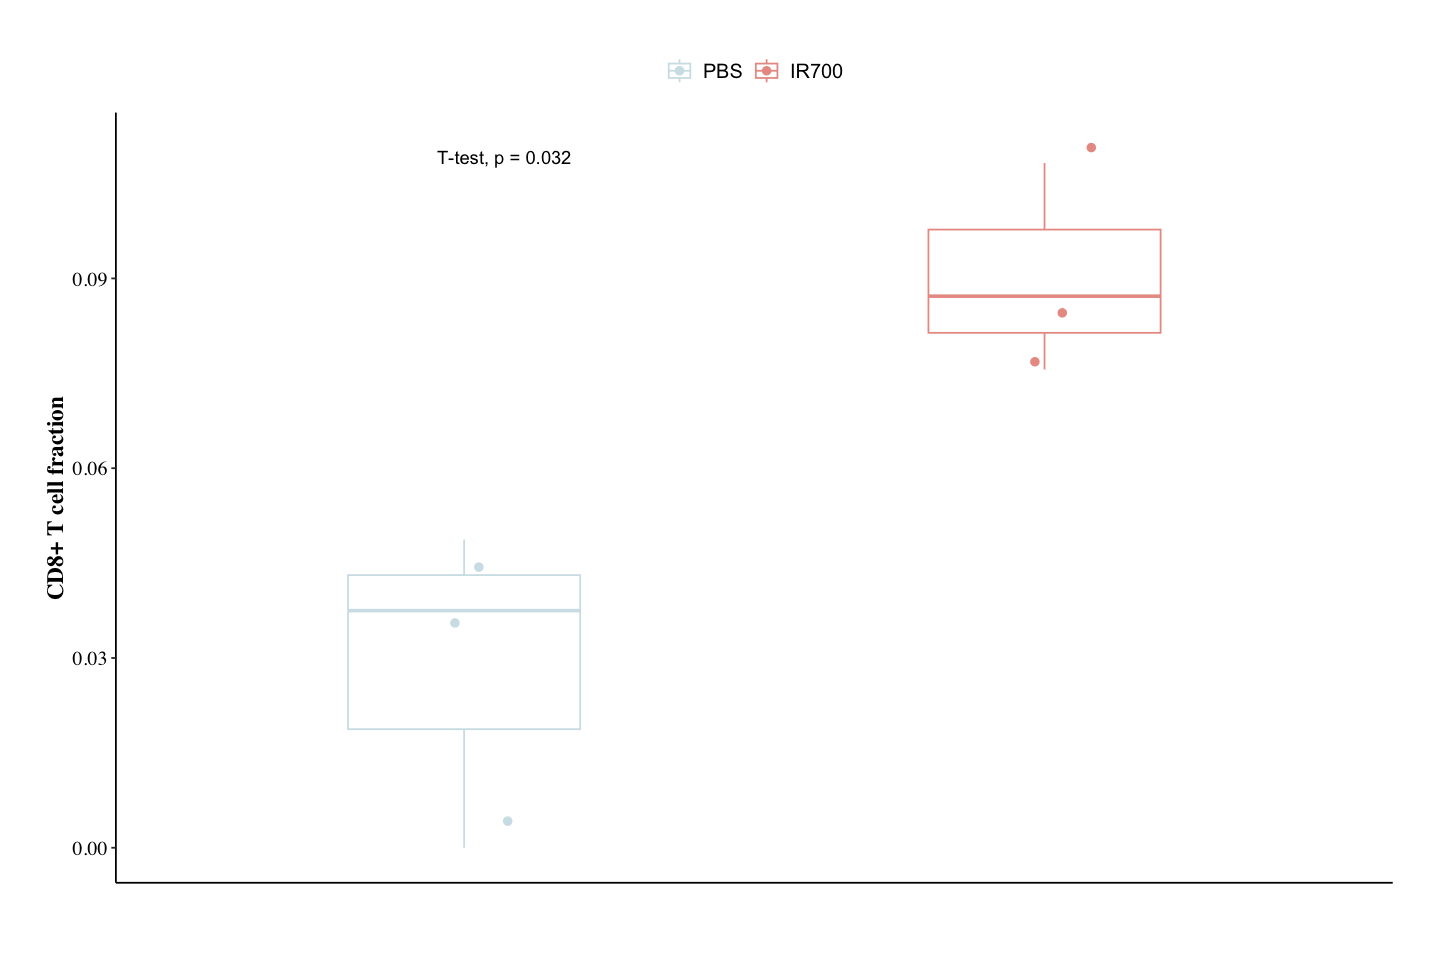

In [ ]:
p1 <- ggplot(plot_data, aes(x = Group, y = Composition)) +
        #geom_violin(aes(fill = Group, colour = Group), alpha = 0.8) + 
        geom_boxplot(aes(colour = Group), width = 0.4) + # 添加箱线图图层
        geom_jitter(aes(fill=Group, colour = Group), width =0.1, shape = 21, size=2)+
        labs(x = " ", y = 'CD8+ T cell fraction') +
        scale_fill_manual(values = c("PBS"='#D0E2E8', "Combination"='#CAD4E7', "IR700"='#E99C93', "PD-1"='#F1DBB9'))+ 
        scale_color_manual(values = c("PBS"='#D0E2E8', "Combination"='#CAD4E7', "IR700"='#E99C93', "PD-1"='#F1DBB9'))+ 
        theme_bw() +
        #stat_compare_means(aes(group=Group),method = "anova",label.x = 2.5, label.y = 0.12) + #, label = "p.format"
        stat_compare_means(method="t.test") + #,label="p.signif", ref.group = "PBS", hide.ns = T
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            panel.border = element_blank(),
            axis.line.x = element_line(color="black"), 
            axis.line.y = element_line(color="black"),
            #axis.text.x = element_text(vjust = 0.5, hjust=0.5, family = "Times", colour = "black", size = 12),
            axis.text.x = element_blank(),
            axis.ticks.x = element_blank(),
            axis.text.y = element_text(vjust = 0.5, hjust=0.5, family = "Times", colour = "black", size = 12),
            axis.title.x = element_text(vjust = 0.5, hjust=0.5, family = "Times", colour = "black", size = 14,face = 'bold'),
            axis.title.y = element_text(vjust = 1, hjust=0.5, family = "Times", colour = "black", size = 14,face = 'bold'),
          plot.margin = unit(c(1, 1, 1, 1), units = , "cm"),
          legend.text = element_text(size = 12),          
          legend.title = element_blank(),                              
          legend.position = "top", 
          legend.key = element_blank(),
          legend.background = element_rect(color = "black", 
                                           fill = "transparent", 
                                           size = 4, linetype = "blank"))
p1
ggsave(filename="./Cibersort_CD8T2.pdf",plot=p1, width = 4,height = 8)